In [1]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import glob, os
from difflib import get_close_matches
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, leaves_list
from sklearn.decomposition import PCA
from itertools import combinations
import re
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import pdist, squareform
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import spearmanr, pearsonr
from dash import Dash, dcc, html, Input, Output, no_update
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import spearmanr, pearsonr
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import VarianceThreshold
from sklearn.base import BaseEstimator, TransformerMixin
from scipy.cluster.hierarchy import linkage, fcluster, leaves_list
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.model_selection import LeaveOneOut, cross_val_predict





# Combining Sample and Control Files (qc, blank, env blank) for later removing contamination

In [2]:

# listing  the compounds samples data extracted by Nist library of unknown compound software
sample_files = [
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_7.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_9.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_14.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_21.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_28.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_44.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_53.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_55.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_83.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_92.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_7.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_6.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_10.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_38.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_42.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_48.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_56.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_76.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_79.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_86.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_5.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_16.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_39.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_50.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_60.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_68.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_81.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_87.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_66.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_4.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_8.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_37.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_43.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_51.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_57.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_61.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_18.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_75.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_94.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_1.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_35.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_30.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_71.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_73.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_88.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_93.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_12.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_36.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_15.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_25.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_40.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_41.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_45.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_59.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_74.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_77.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_49.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_2.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_24.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_31.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_32.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_34.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_90.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_58.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_64.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_70.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_78.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_22.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_26.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_47.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_52.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_65.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_67.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_54.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_80.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_82.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_85.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_3.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_13.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_17.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_20.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_23.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_27.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_29.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_62.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_72.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_11.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_19.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_33.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_46.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_63.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_69.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_84.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_89.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_91.csv",

]
# Replace these with  actual QC, env, blank file paths beacuse we want to remove the contamination and get the actual peaks for samples
qc_files= glob.glob(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\QC_*.csv")
env_files= glob.glob(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\env_*.csv")
blank_files= glob.glob(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\blank_*.csv")
all_files = (
    [(f,"sample") for f in sample_files] +
    [(f, "qc") for f in qc_files] +
    [(f, "env") for f in env_files] +
    [(f, "blank") for f in blank_files]
)
rows = []
for fp, ftype in all_files:
    df = pd.read_csv(fp)
    df["FileType"] = ftype
    df["FileName"] = fp.split("\\")[-1]
    rows.append(df)
compound_df = pd.concat(rows, ignore_index=True)
output_path = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\compound_analysis\combined.csv"

# Save to CSV to use it later
compound_df .to_csv(output_path, index=False)
print(f"compound dataset saved to: {output_path}")
compound_df.head()

compound dataset saved to: C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\compound_analysis\combined.csv


,Component RT,Compound Name,Match Factor,Best Hit,Formula,FileType,FileName
0,2.185667,"2-Propanone, 1-methoxy-",91.035716,True,C4H8O2,sample,sample_7.csv
1,2.899483,"Butanal, 3-methyl-",95.554383,True,C5H10O,sample,sample_7.csv
2,3.317483,Pentanal,91.360114,True,C5H10O,sample,sample_7.csv
3,4.069867,"Disulfide, dimethyl",94.565354,True,C2H6S2,sample,sample_7.csv
4,5.282067,Hexanal,93.609765,True,C6H12O,sample,sample_7.csv


# Filtering True Sample Compounds

In [3]:
# removing the compounds of in blanks/QCs/env
exclude = compound_df.loc[
    compound_df['FileType'].isin(['blank', 'env', 'qc']),
    'Compound Name'
].unique()

# Keep only actual sample compounds, removing excluded ones
real = compound_df.loc[
    (compound_df['FileType'] == 'sample') &
    (~compound_df['Compound Name'].isin(exclude))
].copy()

# Print filtered data shape and show head
print("Filtered sample compounds:", real.shape)
real.head()

Filtered sample compounds: (2394, 7)


,Component RT,Compound Name,Match Factor,Best Hit,Formula,FileType,FileName
0,2.185667,"2-Propanone, 1-methoxy-",91.035716,True,C4H8O2,sample,sample_7.csv
1,2.899483,"Butanal, 3-methyl-",95.554383,True,C5H10O,sample,sample_7.csv
2,3.317483,Pentanal,91.360114,True,C5H10O,sample,sample_7.csv
3,4.069867,"Disulfide, dimethyl",94.565354,True,C2H6S2,sample,sample_7.csv
4,5.282067,Hexanal,93.609765,True,C6H12O,sample,sample_7.csv


In [4]:
# the cleaned_sample_data is the sample data after prepration 
cleaned_sample_data=pd.read_csv(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\cleaned_features_with_meta.csv")

# Build sample_matching dictionary automatically
sample_matching = {}
for col in cleaned_sample_data.columns:
    match = re.search(r'S96_(\d+)_B1_D\d+_T1', col)
    if match:
        sample_num = match.group(1)
        filename = f'sample_{sample_num}.csv'
        sample_matching[filename] = col

# Manually add missing samples 46 and 47
sample_matching['sample_46.csv'] = 's179 S96_46_B1_D10_T2'
sample_matching['sample_47.csv'] = 's148 S96_47_B1_D8_T2'

print("Sample matching dictionary with added missing samples:")
print(sample_matching)

# Define function to find closest peak by RT with tolerance
def find_closest_peak(rt, peaks_rt, tol=0.1):
    diffs = np.abs(peaks_rt - rt)
    min_diff = diffs.min()
    if min_diff <= tol:
        return diffs.idxmin()  # index of closest peak
    else:
        return None

# Match compounds to intensities in cleaned_sample_data
matches = []
peaks_rt = cleaned_sample_data['tR_best']

for i, row in compound_df.iterrows():
    file_name = row['FileName']
    sample_col = sample_matching.get(file_name)
    if sample_col is None:
        # No matching sample column found for this compound
        continue
    
    compound_rt = row['Component RT']
    peak_idx = find_closest_peak(compound_rt, peaks_rt)
    
    if peak_idx is None:
        # No peak found within tolerance for this compound RT
        continue
    
    intensity = cleaned_sample_data.loc[peak_idx, sample_col]
    
    matches.append({
        'Compound Name': row['Compound Name'],
        'FileName': file_name,
        'Sample': sample_col,
        'Component RT': compound_rt,
        'Peak': cleaned_sample_data.loc[peak_idx, 'Peak'],
        'tR_best': cleaned_sample_data.loc[peak_idx, 'tR_best'],
        'm/z': cleaned_sample_data.loc[peak_idx, 'm/z'],
        'Intensity': intensity
    })

#  final matched DataFrame
compound_intesity_df = pd.DataFrame(matches)

print(f"Number of matched compound intensities: {compound_intesity_df .shape[0]}")
print(compound_intesity_df .head())
print(compound_intesity_df.shape)

Sample matching dictionary with added missing samples:
{'sample_10.csv': 's26 S96_10_B1_D2_T1', 'sample_11.csv': 's169 S96_11_B1_D10_T1', 'sample_12.csv': 's78 S96_12_B1_D5_T1', 'sample_13.csv': 's153 S96_13_B1_D9_T1', 'sample_14.csv': 's2 S96_14_B1_D1_T1', 'sample_15.csv': 's93 S96_15_B1_D6_T1', 'sample_16.csv': 's39 S96_16_B1_D3_T1', 'sample_17.csv': 's151 S96_17_B1_D9_T1', 'sample_18.csv': 's59 S96_18_B1_D4_T1', 'sample_19.csv': 's174 S96_19_B1_D10_T1', 'sample_1.csv': 's80 S96_1_B1_D5_T1', 'sample_20.csv': 's152 S96_20_B1_D9_T1', 'sample_21.csv': 's6 S96_21_B1_D1_T1', 'sample_22.csv': 's137 S96_22_B1_D8_T1', 'sample_23.csv': 's154 S96_23_B1_D9_T1', 'sample_24.csv': 's119 S96_24_B1_D7_T1', 'sample_25.csv': 's95 S96_25_B1_D6_T1', 'sample_26.csv': 's140 S96_26_B1_D8_T1', 'sample_27.csv': 's157 S96_27_B1_D9_T1', 'sample_28.csv': 's4 S96_28_B1_D1_T1', 'sample_29.csv': 's150 S96_29_B1_D9_T1', 'sample_2.csv': 's114 S96_2_B1_D7_T1', 'sample_30.csv': 's79 S96_30_B1_D5_T1', 'sample_31.csv': 

# Checking the presence of known potato aroma compounds

In [5]:

potato_aromas = [
    "Hexanal", "Nonanal", "Pentanal", "2-Methylbutanal", "3-Methylbutanal",
    "1-Octen-3-ol", "Benzaldehyde", "1-Phenylethanol", "Methional",
    "Dimethyl trisulfide", "Furfural", "2,3-Butanedione", "Ethyl butanoate",
    "2-Acetylpyrazine", "Dimethyl disulfide", "2-Propanone, 1-methoxy-",
    "Cyclotrisiloxane, hexamethyl-", "3-Octanone", "Hexanol", "Butanal, 3-methyl-",
    "Heptanal", "Octanal", "Decanal",
    "2-Heptanone", "2-Nonanone", "3-Heptanone",
    "Ethyl hexanoate", "Methyl butanoate", "Ethyl 2-methylbutanoate",
    "2-Ethyl-3,5-dimethylpyrazine", "2-Isobutyl-3-methoxypyrazine",
    "1-Heptanol", "1-Nonanol",
    "Methanethiol", "Dimethyl tetrasulfide", "Carbon disulfide",
    "Acetic acid", "Butanoic acid", "Hexanoic acid"
]

def normalize(name):
    return name.lower().replace(' ', '').replace('-', '').replace(',', '')

# Normalize aroma list into dictionary: normalized name -> original name
ref_norm = {normalize(x): x for x in potato_aromas}

# Normalize compound names in matched_df
compound_intesity_df['norm_name'] = compound_intesity_df['Compound Name'].apply(normalize)

# Exact matches
compound_intesity_df['is_aroma'] =compound_intesity_df['norm_name'].isin(ref_norm)

# Fuzzy matching for compounds not exactly matched
def fuzzy_match(n, refs, cutoff=0.8):
    matches = get_close_matches(n, refs, n=1, cutoff=cutoff)
    return matches[0] if matches else None

mask = ~compound_intesity_df['is_aroma']
fuzzy_hits = compound_intesity_df.loc[mask, 'norm_name'].map(lambda n: fuzzy_match(n, list(ref_norm.keys())))

# Mark fuzzy matched as aroma and update 'Compound Name' with official name
compound_intesity_df.loc[mask & fuzzy_hits.notna(), 'is_aroma'] = True
compound_intesity_df.loc[mask & fuzzy_hits.notna(), 'Compound Name'] = fuzzy_hits.map(ref_norm)

# Filter only aroma compounds
aroma_sample_df = compound_intesity_df[compound_intesity_df['is_aroma']].copy()

print(f"Number of aroma compound records: {aroma_sample_df.shape[0]}")
print(aroma_sample_df.head())

len(aroma_sample_df['Sample'].unique())


Number of aroma compound records: 570
                   Compound Name      FileName              Sample  \
0             Butanal, 3-methyl-  sample_7.csv  s18 S96_7_B1_D1_T1   
1                       Pentanal  sample_7.csv  s18 S96_7_B1_D1_T1   
3                        Hexanal  sample_7.csv  s18 S96_7_B1_D1_T1   
4  Cyclotrisiloxane, hexamethyl-  sample_7.csv  s18 S96_7_B1_D1_T1   
5                   Benzaldehyde  sample_7.csv  s18 S96_7_B1_D1_T1   

   Component RT  Peak  tR_best  m/z  Intensity                   norm_name  \
0      2.899483    27    2.890   44  15.879306              butanal3methyl   
1      3.317483    41    3.375   81  19.455887                    pentanal   
3      5.282067    73    5.199  149  15.227984                     hexanal   
4      5.883333    80    5.903  207  17.026906  cyclotrisiloxanehexamethyl   
5      9.314117   145    9.347  267  17.161132                benzaldehyde   

   is_aroma  
0      True  
1      True  
3      True  
4      True  
5 

94

# Map variety on samples to do analysis by varaiety instead of by sample name

In [6]:
# since the variety names are not consistent in aroma_mapped_clean, we need to match them to the master table   
# Loading the master table
master = pd.read_csv(
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\files\project file\GCMS Steamed 96 set 2024- Mastertable(Sheet1).csv"
)

# Extract SampleNumber 
aroma_sample_df['SampleNumber'] = aroma_sample_df['FileName'].str.extract(r'(\d+)').astype(int)

# Filtering master table to exclude blanks/QC etc for just getting the valid samples
valid_master = master[
    ~master['Sample'].isin(['Blank', 'QCB', 'QC1', 'QC2', 'QC3', 'QC4', 'EnvBlank'])
].copy()

valid_master['SampleNumber'] = valid_master['Filename'].str.extract(r'_([0-9]+)_B').astype(int)

# Extract Variety from master 'Sample' column
valid_master['Variety'] = valid_master['Sample'].str.split(';').str[-1].str.strip()

# Prepare  table
sample_to_variety = valid_master[['SampleNumber', 'Variety']].drop_duplicates()

# Merge variety info into aroma_samples by SampleNumber
aroma_per_variety = pd.merge(aroma_sample_df, sample_to_variety, on='SampleNumber', how='left')

# Drop the FileName column beacuse we do not need it anymore
aroma_per_variety = aroma_per_variety.drop(columns=['FileName'])
print(aroma_per_variety)



                     Compound Name                 Sample  Component RT  Peak  \
0               Butanal, 3-methyl-     s18 S96_7_B1_D1_T1      2.899483    27   
1                         Pentanal     s18 S96_7_B1_D1_T1      3.317483    41   
2                          Hexanal     s18 S96_7_B1_D1_T1      5.282067    73   
3    Cyclotrisiloxane, hexamethyl-     s18 S96_7_B1_D1_T1      5.883333    80   
4                     Benzaldehyde     s18 S96_7_B1_D1_T1      9.314117   145   
..                             ...                    ...           ...   ...   
565  Cyclotrisiloxane, hexamethyl-  s171 S96_89_B1_D10_T1      5.886600    80   
566                   Benzaldehyde  s171 S96_89_B1_D10_T1      9.333467   145   
567  Cyclotrisiloxane, hexamethyl-  s173 S96_91_B1_D10_T1      5.886867    80   
568                   Benzaldehyde  s173 S96_91_B1_D10_T1      9.334584   145   
569                        Decanal  s173 S96_91_B1_D10_T1     13.722683   274   

     tR_best  m/z  Intensit

# Full dataframe including the variety, aroma compounds and their description.

In [7]:
aroma_descriptions = {
    "Butanal, 3-methyl-": "Fruity, malty, chocolate",
    "Pentanal": "Green, fatty, pungent",
    "Hexanal": "Green, grassy",
    "Cyclotrisiloxane, hexamethyl-": "Chemical, silicone-like",
    "Benzaldehyde": "Almond, cherry, fruity",
    "Dimethyl trisulfide": "Garlic, onion, sulfurous",
    "Furfural": "Sweet, almond, caramel",
    "Methional": "Cooked potato, sulfurous",
    "Octanal": "Citrus, fruity",
    "Decanal": "Citrus, floral",
    "Hexanoic acid": "Fatty, cheesy, sweaty",
    "2,3-Butanedione": "Butter, creamy, sweet",
    "2-Acetylpyrazine": "Nutty, roasted",
    "Ethyl butanoate": "Fruity, pineapple, sweet",
    "Ethyl hexanoate": "Fruity, apple, pineapple",
    "Methyl butanoate": "Fruity, apple, sweet",
    "Ethyl 2-methylbutanoate": "Fruity, apple, sweet",
    "2-Ethyl-3,5-dimethylpyrazine": "Nutty, roasted, earthy",
    "2-Isobutyl-3-methoxypyrazine": "Green, bell pepper",
    "1-Heptanol": "Floral, herbal",
    "1-Nonanol": "Floral, waxy",
    "Methanethiol": "Sulfurous, cabbage",
    "Dimethyl tetrasulfide": "Garlic, sulfurous",
    "Carbon disulfide": "Sulfurous",
    "Acetic acid": "Vinegar, sour",
    "Butanoic acid": "Sweaty, cheesy",
    "2-Propanone, 1-methoxy-": "Solvent, chemical",
    "Cyclotrisiloxane, hexamethyl-": "Chemical, silicone-like",
    "3-Octanone": "Mushroom, earthy",
    "1-Phenylethanol": "Floral, rose",
    "2-Methylbutanal": "Malty, chocolate",
    "3-Methylbutanal": "Malty, chocolate",
    "1-Octen-3-ol": "Mushroom, earthy",
    "Dimethyl disulfide": "Garlic, onion",
    "Ethyl 2-methylbutanoate": "Fruity, apple",
}

aroma_per_variety['Aroma Description'] = aroma_per_variety['Compound Name'].map(aroma_descriptions)
print(aroma_per_variety.head(20))

                    Compound Name              Sample  Component RT  Peak  \
0              Butanal, 3-methyl-  s18 S96_7_B1_D1_T1      2.899483    27   
1                        Pentanal  s18 S96_7_B1_D1_T1      3.317483    41   
2                         Hexanal  s18 S96_7_B1_D1_T1      5.282067    73   
3   Cyclotrisiloxane, hexamethyl-  s18 S96_7_B1_D1_T1      5.883333    80   
4                    Benzaldehyde  s18 S96_7_B1_D1_T1      9.314117   145   
5             Dimethyl trisulfide  s18 S96_7_B1_D1_T1      9.519900   149   
6                         Octanal  s18 S96_7_B1_D1_T1     10.191900   172   
7                         Decanal  s18 S96_7_B1_D1_T1     13.703067   274   
8              Butanal, 3-methyl-   s3 S96_9_B1_D1_T1      2.899650    27   
9                         Hexanal   s3 S96_9_B1_D1_T1      5.282233    73   
10  Cyclotrisiloxane, hexamethyl-   s3 S96_9_B1_D1_T1      5.886717    80   
11                   Benzaldehyde   s3 S96_9_B1_D1_T1      9.314283   145   

# Doing analysis on aroma compounds for varieties

# - Aroma intensities per variety

In [8]:
# doing pivot to turn  long/tidy table into a feature matrix that’s perfect for analysis.
aroma_pivot = aroma_per_variety.pivot_table(index='Variety', columns='Compound Name', values='Intensity', aggfunc='mean').fillna(0)
print(aroma_pivot.head())

Compound Name  1-Nonanol  2,3-Butanedione  Benzaldehyde  Butanal, 3-methyl-  \
Variety                                                                       
ADORA                0.0              0.0     17.984870           15.836435   
AGRIA                0.0              0.0     14.859493           14.154847   
ALOUETTE             0.0              0.0     15.205705           15.262178   
ALTHEA               0.0              0.0     19.535081           14.984406   
ALTURAS              0.0              0.0     20.293776           14.482897   

Compound Name  Cyclotrisiloxane, hexamethyl-    Decanal  Dimethyl trisulfide  \
Variety                                                                        
ADORA                              17.417208  18.203338              0.00000   
AGRIA                              15.947810  14.499810             17.21077   
ALOUETTE                           14.678352  17.462371              0.00000   
ALTHEA                             17.704453  

In [9]:
# Reset the index to make 'Variety' a normal column again
aroma_pivot_reset = aroma_pivot.reset_index()

# Rename columns with descriptions while keeping 'Variety' column unchanged
aroma_pivot_renamed = aroma_pivot_reset.copy()
aroma_pivot_renamed.columns = ['Variety'] + [
    f"{compound} ({aroma_descriptions.get(compound, 'No description')})"
    for compound in aroma_pivot_reset.columns[1:]
]
print(aroma_pivot_renamed.head())

    Variety  1-Nonanol (Floral, waxy)  \
0     ADORA                       0.0   
1     AGRIA                       0.0   
2  ALOUETTE                       0.0   
3    ALTHEA                       0.0   
4   ALTURAS                       0.0   

   2,3-Butanedione (Butter, creamy, sweet)  \
0                                      0.0   
1                                      0.0   
2                                      0.0   
3                                      0.0   
4                                      0.0   

   Benzaldehyde (Almond, cherry, fruity)  \
0                              17.984870   
1                              14.859493   
2                              15.205705   
3                              19.535081   
4                              20.293776   

   Butanal, 3-methyl- (Fruity, malty, chocolate)  \
0                                      15.836435   
1                                      14.154847   
2                                      15.262178   
3  

Doing PCA on aroma intensities

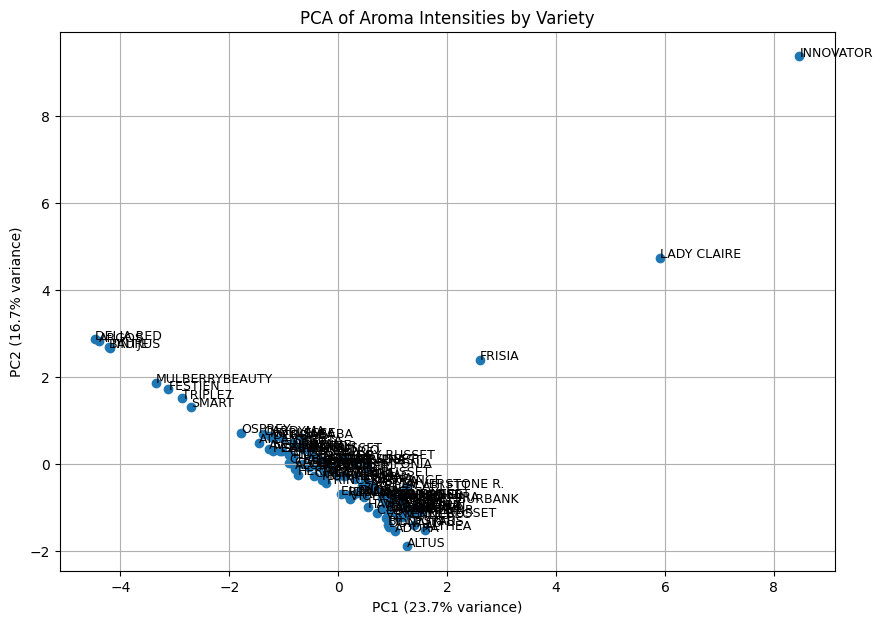

In [10]:
# If 'Variety' is a column, set it as index:
if 'Variety' in aroma_pivot_renamed.columns:
    aroma_pivot_renamed.set_index('Variety', inplace=True)

# Now extract numeric data
X_numeric = aroma_pivot_renamed.values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,7))
plt.scatter(X_pca[:, 0], X_pca[:, 1])

# Use the index (varieties) for labels
for i, variety in enumerate(aroma_pivot_renamed.index):
    plt.text(X_pca[i, 0], X_pca[i, 1], variety, fontsize=9)

plt.xlabel('PC1 (%.1f%% variance)' % (pca.explained_variance_ratio_[0]*100))
plt.ylabel('PC2 (%.1f%% variance)' % (pca.explained_variance_ratio_[1]*100))
plt.title('PCA of Aroma Intensities by Variety')
plt.grid(True)
plt.show()

In [11]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=aroma_pivot_renamed.columns,
    columns=['PC1','PC2']
)

# Top contributors (absolute) to each PC:
for pc in ['PC1','PC2']:
    print(pc, loadings[pc].abs().sort_values(ascending=False).head(10))


PC1 Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like)    0.437942
Benzaldehyde (Almond, cherry, fruity)                      0.408805
Methional (Cooked potato, sulfurous)                       0.343439
Furfural (Sweet, almond, caramel)                          0.331980
Decanal (Citrus, floral)                                   0.318618
Butanal, 3-methyl- (Fruity, malty, chocolate)              0.302503
2,3-Butanedione (Butter, creamy, sweet)                    0.284577
Hexanal (Green, grassy)                                    0.217397
Dimethyl trisulfide (Garlic, onion, sulfurous)             0.210216
Octanal (Citrus, fruity)                                   0.140251
Name: PC1, dtype: float64
PC2 Methional (Cooked potato, sulfurous)                       0.478761
Furfural (Sweet, almond, caramel)                          0.461024
2,3-Butanedione (Butter, creamy, sweet)                    0.447512
Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like)    0.297927
Benzaldehyde (

# PCA

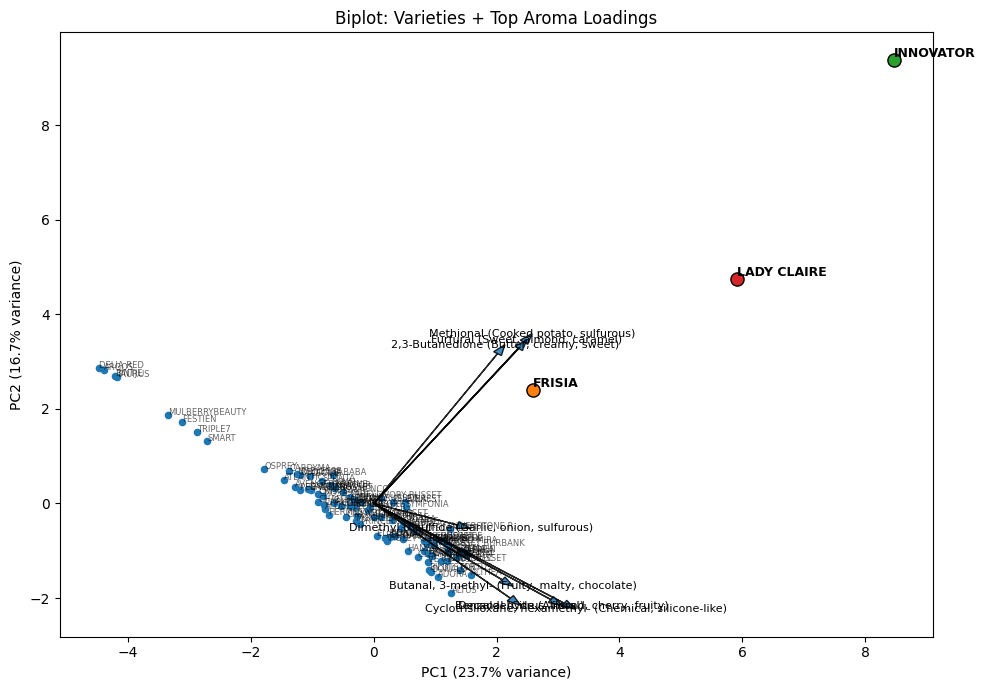

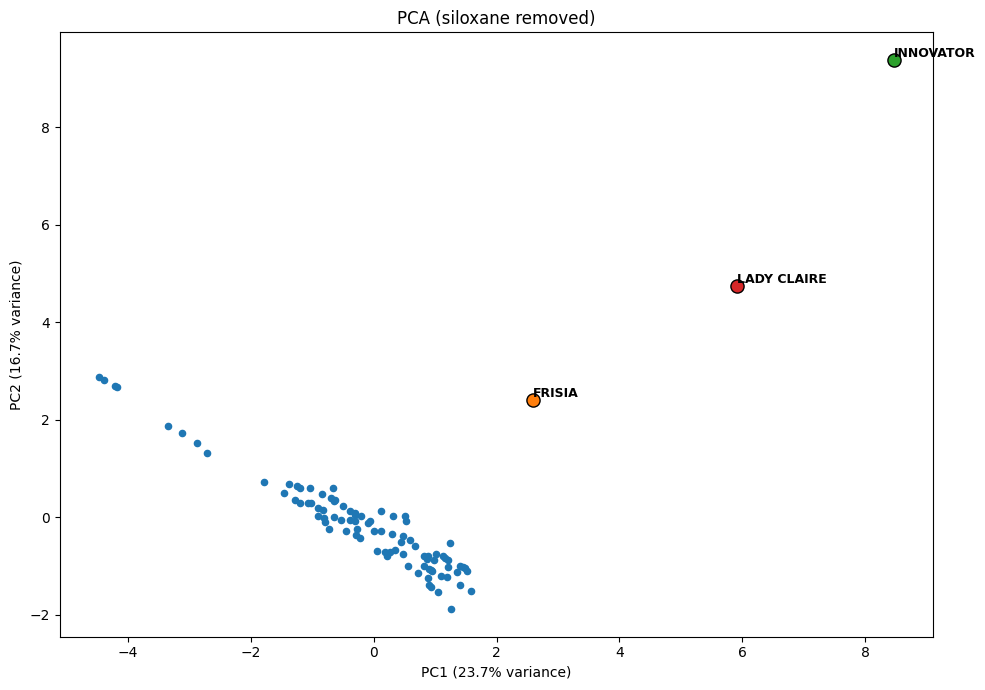


Top 10 farthest varieties (after removing siloxane):
INNOVATOR         12.638177
LADY CLAIRE        7.578308
DELIA RED          5.311601
ARGOS              5.225179
BINTJE             4.998083
TAURUS             4.972511
MULBERRYBEAUTY     3.840941
FESTIEN            3.560761
FRISIA             3.536808
TRIPLE7            3.247057
dtype: float64


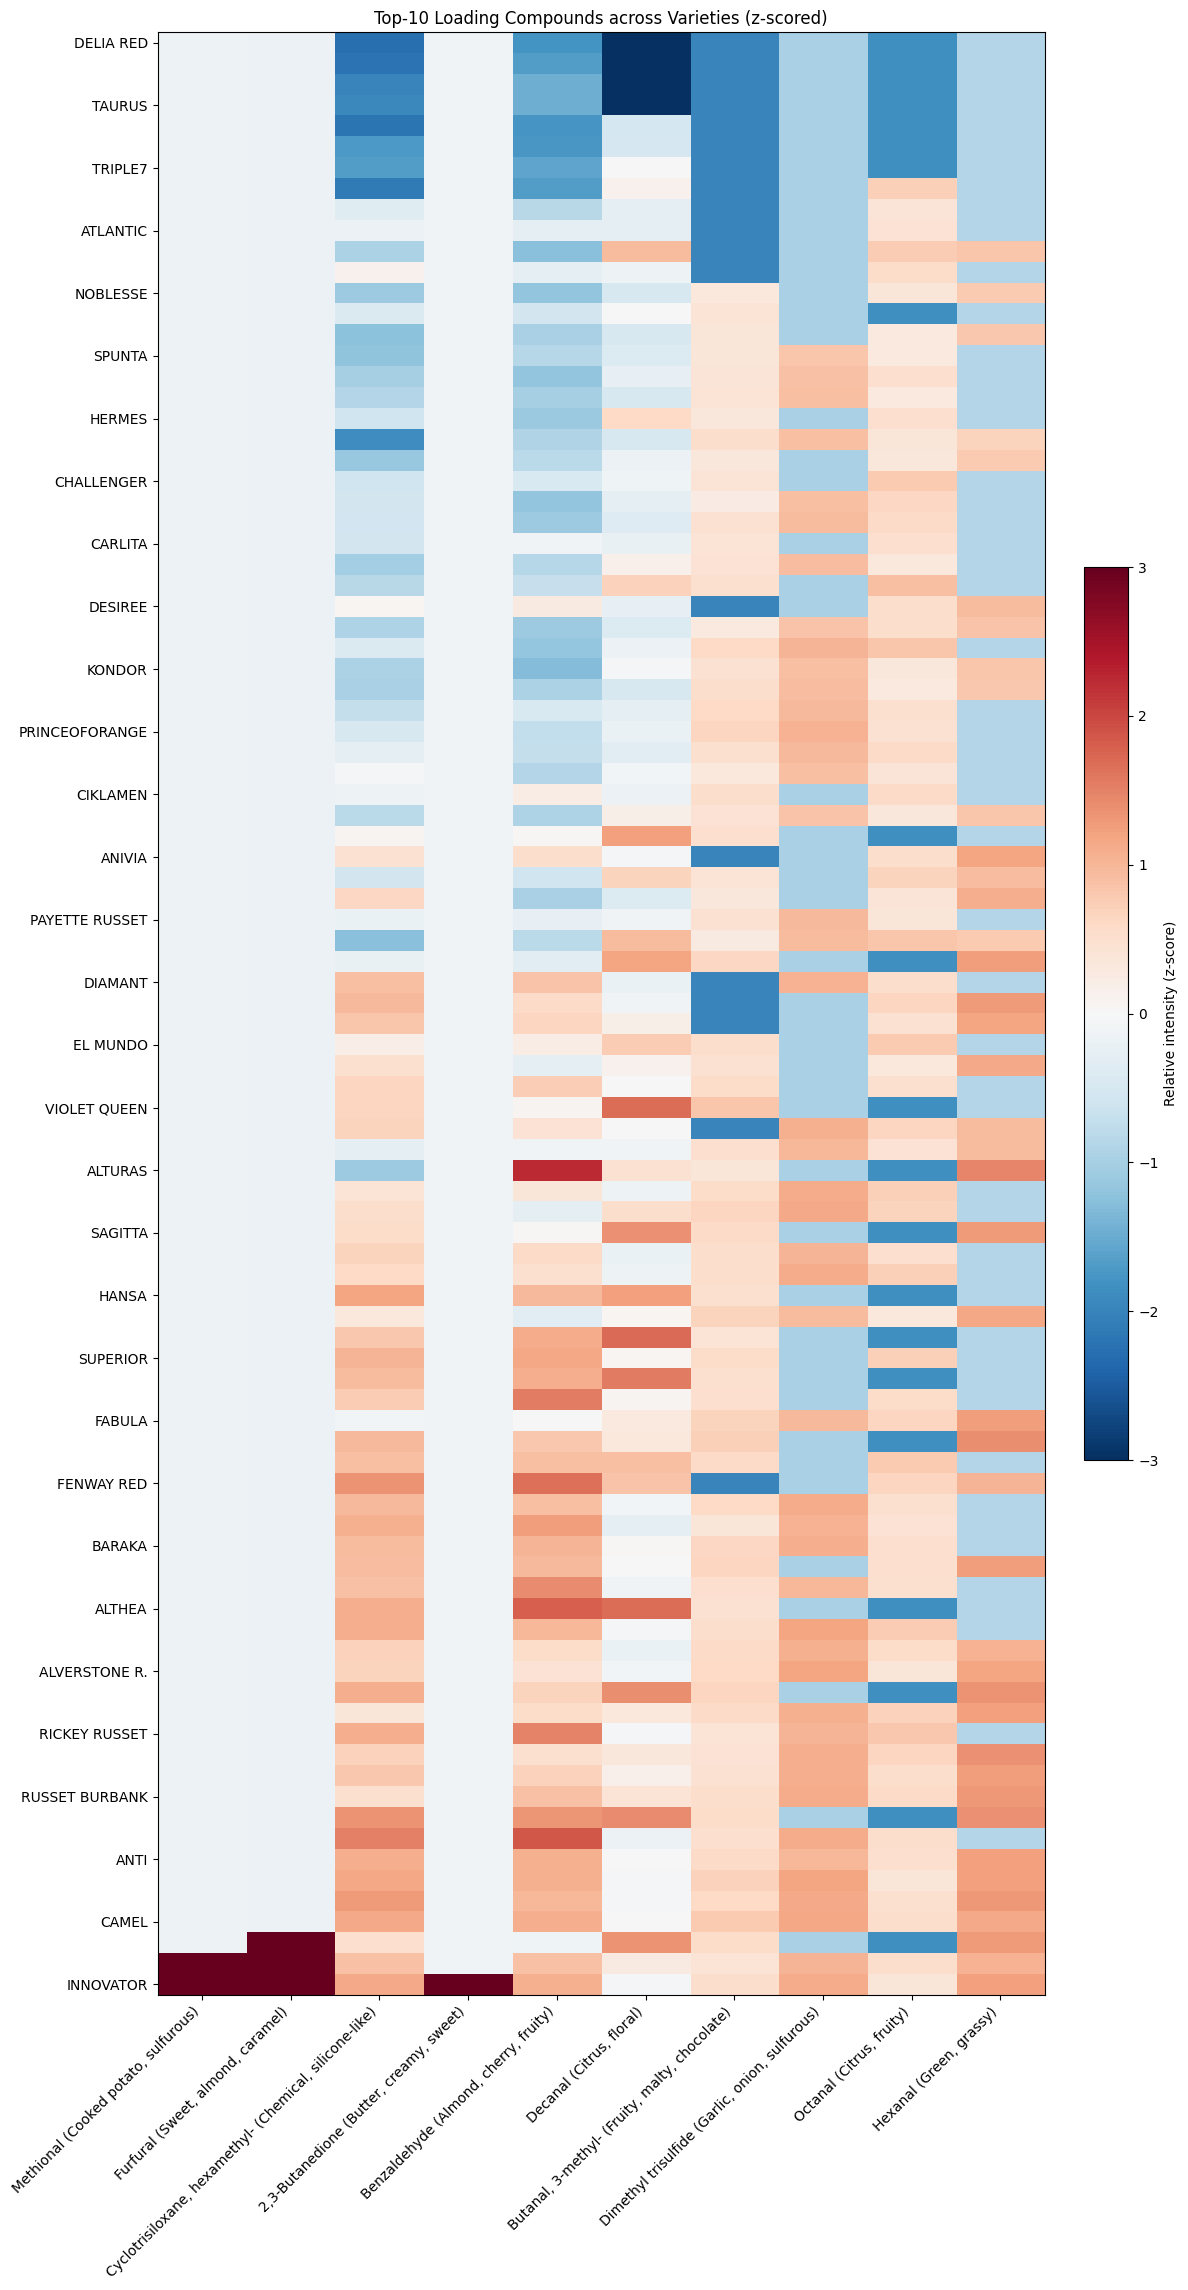

In [12]:
# PCA biplot + PCA without siloxane + Heatmap 

# I expect this table in memory: rows = Variety, columns = compounds (numerical)
assert 'aroma_pivot_renamed' in globals(), "Please define aroma_pivot_renamed first."

# PCA function (2 components)
def run_pca_2d(df):
    # standardize columns (mean=0, std=1)
    scaler = StandardScaler()
    Xz = scaler.fit_transform(df.values)

    # fit PCA with 2 components
    pca = PCA(n_components=2, random_state=0)
    scores = pca.fit_transform(Xz)  # coordinates of varieties in PC space

    # loadings = contribution of each compound to PC1 and PC2
    loadings = pd.DataFrame(pca.components_.T, index=df.columns, columns=['PC1','PC2'])
    return pca, scores, loadings

# Biplot on all compounds 
pca, scores, loadings = run_pca_2d(aroma_pivot_renamed)

plt.figure(figsize=(10,7))
plt.scatter(scores[:,0], scores[:,1], s=20)

# label a few varieties
names = aroma_pivot_renamed.index.tolist()
focus = {'INNOVATOR','LADY CLAIRE','FRISIA'}
for i, name in enumerate(names):
    if name.upper() in focus:
        plt.scatter(scores[i,0], scores[i,1], s=90, edgecolor='k')
        plt.text(scores[i,0], scores[i,1], name, fontsize=9, fontweight='bold',
                 ha='left', va='bottom')
    else:
        # small, faint labels for the rest 
        plt.text(scores[i,0], scores[i,1], name, fontsize=6, alpha=0.6)

# show arrows for top 8 compounds by |loading PC1|+|loading PC2|
topk = 8
importance = loadings.abs().sum(axis=1).sort_values(ascending=False)
top_feats = importance.head(topk).index

# scale arrows so they fit in the plot
scale = 0.8 * np.max(np.abs(scores))
for feat in top_feats:
    x = loadings.loc[feat, 'PC1'] * scale
    y = loadings.loc[feat, 'PC2'] * scale
    plt.arrow(0, 0, x, y, head_width=0.15, length_includes_head=True, alpha=0.85)
    plt.text(x, y, feat, fontsize=8, ha='center', va='center')

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("Biplot: Varieties + Top Aroma Loadings")
plt.tight_layout()
plt.show()

# PCA after removing the siloxane column 
silox = "Cyclotrisiloxane, hexamethyl-"
cols_keep = [c for c in aroma_pivot_renamed.columns if c.lower() != silox.lower()]
aroma_no_silox = aroma_pivot_renamed[cols_keep]

pca2, scores2, loadings2 = run_pca_2d(aroma_no_silox)

plt.figure(figsize=(10,7))
plt.scatter(scores2[:,0], scores2[:,1], s=20)
for i, name in enumerate(names):
    if name.upper() in focus:
        plt.scatter(scores2[i,0], scores2[i,1], s=90, edgecolor='k')
        plt.text(scores2[i,0], scores2[i,1], name, fontsize=9, fontweight='bold',
                 ha='left', va='bottom')
plt.xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("PCA (siloxane removed)")
plt.tight_layout()
plt.show()

# Simple outlier check 
dist = np.sqrt(scores2[:,0]**2 + scores2[:,1]**2)
rank = pd.Series(dist, index=names).sort_values(ascending=False)
print("\nTop 10 farthest varieties (after removing siloxane):")
print(rank.head(10))

# Heatmap for top-10 loading compounds (from the second PCA) 
top10 = loadings2.abs().sum(axis=1).sort_values(ascending=False).head(10).index
sub = aroma_no_silox[top10].copy()

# z-score each compound 
sub_z = (sub - sub.mean()) / sub.std(ddof=0)

# order rows by PC1 of the heatmap matrix 
p = PCA(n_components=2, random_state=0).fit(sub_z.values)
S = p.transform(sub_z.values)
row_order = np.argsort(S[:,0])
sub_z_ord = sub_z.iloc[row_order]

# draw heatmap with a diverging colormap and fixed limits
plt.figure(figsize=(12, max(6, int(0.25*len(sub_z_ord)))))
im = plt.imshow(sub_z_ord.values, aspect='auto', cmap='RdBu_r', vmin=-3, vmax=3)

# thin out y-ticks if there are many rows
step = max(1, len(sub_z_ord)//30)
plt.yticks(np.arange(0, len(sub_z_ord), step), sub_z_ord.index[::step])

plt.xticks(np.arange(len(top10)), top10, rotation=45, ha='right')
plt.title("Top-10 Loading Compounds across Varieties (z-scored)")
cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar.set_label("Relative intensity (z-score)")
plt.tight_layout()
plt.show()


PCA: Most varieties cluster; INNOVATOR and LADY CLAIRE are clear outliers; FRISIA moderately so.

High loadings for Methional, 2,3-Butanedione, and aldehydes (Benzaldehyde/Decanal/Octanal).

Siloxane removed: Pattern stays the same → siloxane isn’t driving the main separation.

Outliers: INNOVATOR strongest; LADY CLAIRE also high; FRISIA mid.

Heatmap: Top-10 compounds show strong red/blue bands in those outliers, matching the biplot.

k=2, silhouette=0.674
k=3, silhouette=0.378
k=4, silhouette=0.280
k=5, silhouette=0.303
k=6, silhouette=0.282
Best k=2 (silhouette=0.674)


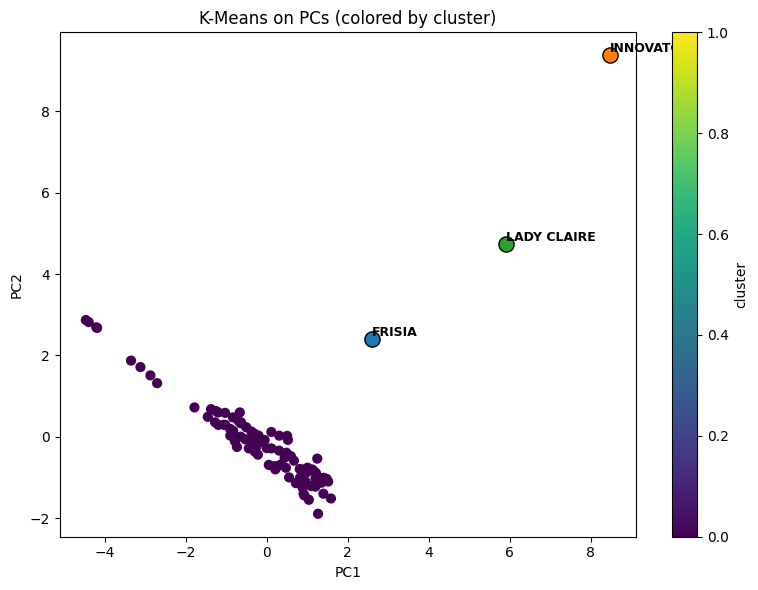

DBSCAN labels value counts: {np.int64(-1): np.int64(34), np.int64(0): np.int64(6), np.int64(1): np.int64(5), np.int64(2): np.int64(10), np.int64(3): np.int64(4), np.int64(4): np.int64(3), np.int64(5): np.int64(3), np.int64(6): np.int64(8), np.int64(7): np.int64(7), np.int64(8): np.int64(3), np.int64(9): np.int64(5), np.int64(10): np.int64(3), np.int64(11): np.int64(3)}


In [13]:

Xz = StandardScaler().fit_transform(aroma_pivot_renamed.values)
pcs = PCA(n_components=6, random_state=0).fit_transform(Xz)  # 6 فقط یک شروع خوب است

best_k, best_s, best_labels = None, -1, None
for k in range(2, 7):
    km = KMeans(n_clusters=k, n_init=20, random_state=0).fit(pcs)
    s = silhouette_score(pcs, km.labels_)
    print(f'k={k}, silhouette={s:.3f}')
    if s > best_s:
        best_k, best_s, best_labels = k, s, km.labels_

print(f'Best k={best_k} (silhouette={best_s:.3f})')

scores_2d = pcs[:, :2]
plt.figure(figsize=(8,6))
sc = plt.scatter(scores_2d[:,0], scores_2d[:,1], c=best_labels, s=40)
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.title('K-Means on PCs (colored by cluster)')
plt.colorbar(sc, label='cluster')

names = aroma_pivot_renamed.index.to_list()
for i, name in enumerate(names):
    if name.upper() in {'INNOVATOR','LADY CLAIRE','FRISIA'}:
        plt.scatter(scores_2d[i,0], scores_2d[i,1], s=120, edgecolor='k')
        plt.text(scores_2d[i,0], scores_2d[i,1], name, fontsize=9, weight='bold',
                 ha='left', va='bottom')
plt.tight_layout(); plt.show()


db = DBSCAN(eps=0.7, min_samples=3).fit(pcs) 
labels_db = db.labels_  
print('DBSCAN labels value counts:', {l: (labels_db==l).sum() for l in np.unique(labels_db)})


Best clustering is k=2 (silhouette 0.674) → strong split.

One large core cluster and a small outlier group; INNOVATOR and LADY CLAIRE are outliers, FRISIA is borderline.

#  Statistics of aroma intensities per variety

In [14]:
# Calculate mean and std of each compound across varieties
desc_stats =aroma_pivot_renamed.describe().T  # transpose to have compounds as rows

# Show top compounds with highest mean intensity overall
top_compounds = desc_stats.sort_values(by='mean', ascending=False).head(10)
print("Top 10 aroma compounds by average intensity:")
print(top_compounds[['mean', 'std']])
aroma_pivot_renamed.head(5)


Top 10 aroma compounds by average intensity:
                                                         mean       std
Benzaldehyde (Almond, cherry, fruity)               16.398647  1.750228
Cyclotrisiloxane, hexamethyl- (Chemical, silico...  15.984822  1.582331
Decanal (Citrus, floral)                            14.820036  3.814669
Octanal (Citrus, fruity)                            13.156437  7.159785
Butanal, 3-methyl- (Fruity, malty, chocolate)       12.223914  6.220205
Dimethyl trisulfide (Garlic, onion, sulfurous)       8.927816  9.188503
Hexanal (Green, grassy)                              6.538783  7.387660
Pentanal (Green, fatty, pungent)                     3.201202  7.406310
Hexanoic acid (Fatty, cheesy, sweaty)                3.034014  7.384243
Furfural (Sweet, almond, caramel)                    0.443991  2.460374


,"1-Nonanol (Floral, waxy)","2,3-Butanedione (Butter, creamy, sweet)","Benzaldehyde (Almond, cherry, fruity)","Butanal, 3-methyl- (Fruity, malty, chocolate)","Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like)","Decanal (Citrus, floral)","Dimethyl trisulfide (Garlic, onion, sulfurous)","Furfural (Sweet, almond, caramel)","Hexanal (Green, grassy)","Hexanoic acid (Fatty, cheesy, sweaty)","Methional (Cooked potato, sulfurous)","Octanal (Citrus, fruity)","Pentanal (Green, fatty, pungent)"
Variety,,,,,,,,,,,,,
ADORA,0.0,0.0,17.984870,15.836435,17.417208,18.203338,0.00000,0.0,0.00000,22.334351,0.0,18.799602,0.000000
AGRIA,0.0,0.0,14.859493,14.154847,15.947810,14.499810,17.21077,0.0,0.00000,0.000000,0.0,15.924101,18.039118
ALOUETTE,0.0,0.0,15.205705,15.262178,14.678352,17.462371,0.00000,0.0,0.00000,0.000000,0.0,19.520823,0.000000
ALTHEA,0.0,0.0,19.535081,14.984406,17.704453,21.158234,0.00000,0.0,0.00000,18.548808,0.0,0.000000,20.209723
ALTURAS,0.0,0.0,20.293776,14.482897,14.257052,16.590508,0.00000,0.0,17.24572,0.000000,0.0,0.000000,0.000000


Overall, aldehydes (benzaldehyde, decanal, octanal) dominate the average aroma signal across varieties.

# Cluster Analysis

Number of unique varieties: 94
Some varieties: ['ADORA', 'AGRIA', 'ALOUETTE', 'ALTHEA', 'ALTURAS', 'ALTUS', 'ALVERSTONE R.', 'ANIVIA', 'ANTI', 'ARDECHE']


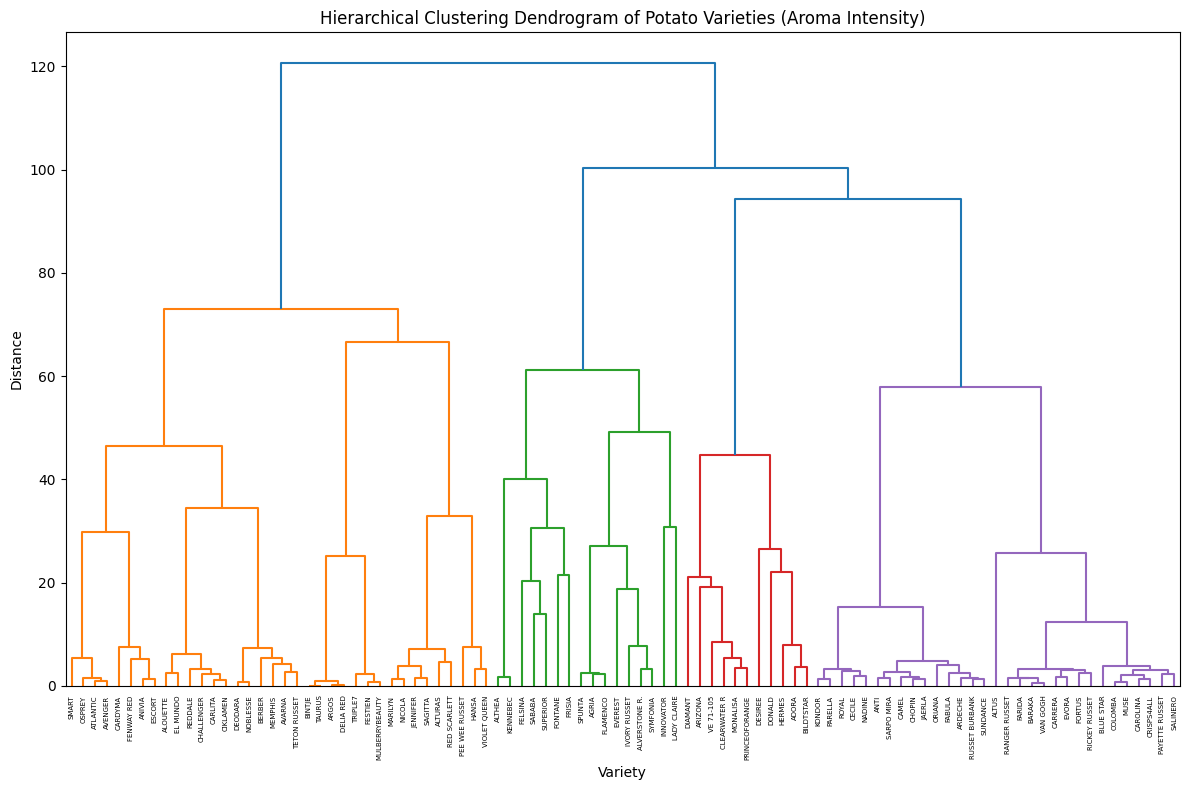

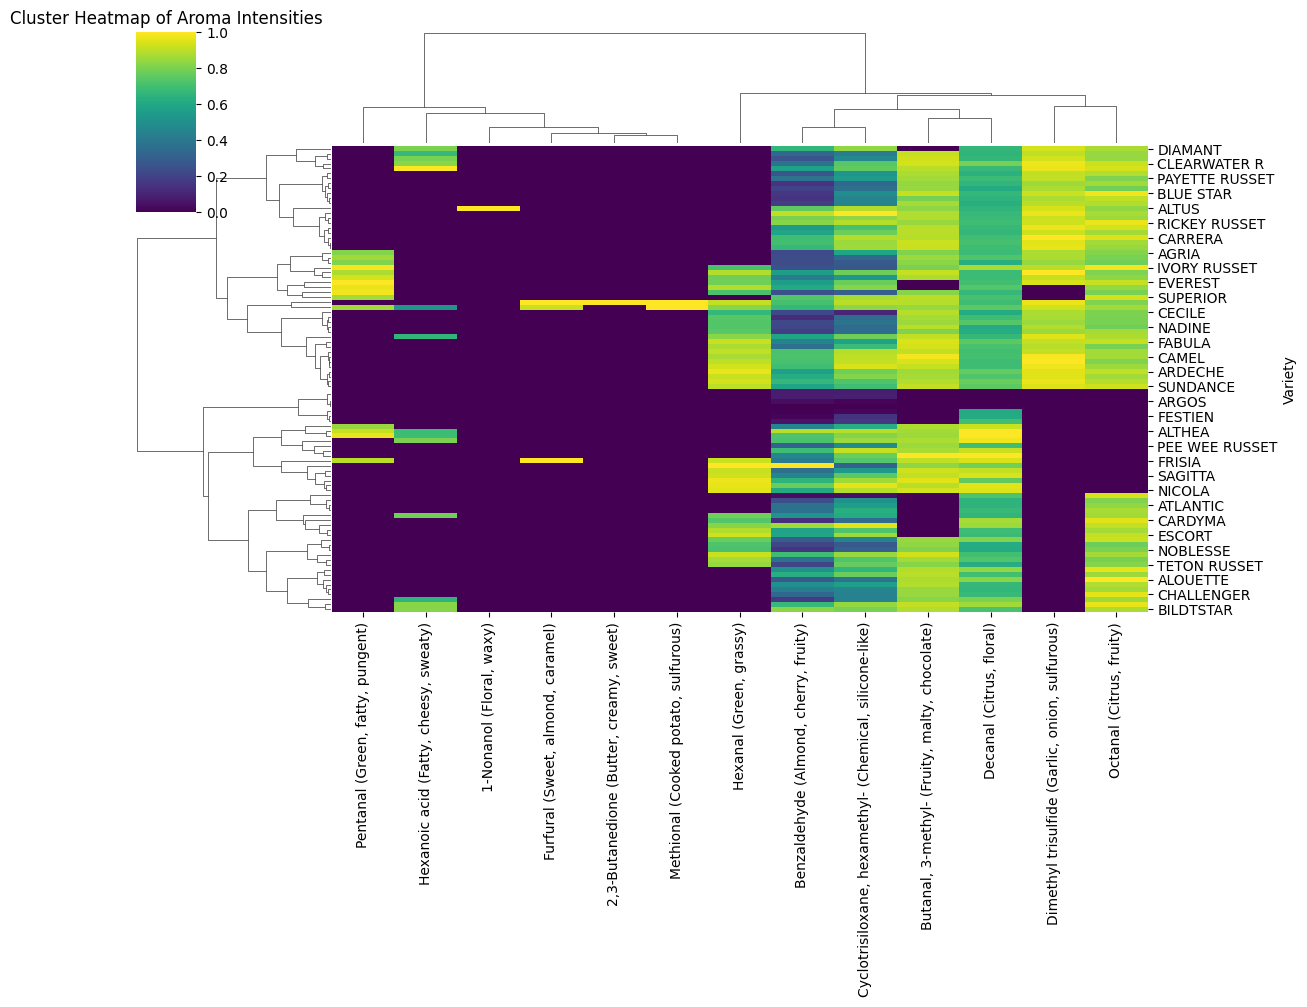

In [15]:
# Number of unique varieties 
num_varieties = aroma_pivot_renamed.index.nunique()
print(f"Number of unique varieties: {num_varieties}")

#see the first few variety names
print("Some varieties:", aroma_pivot_renamed.index[:10].tolist())

# Compute linkage matrix for hierarchical clustering (using Ward's method)
Z = linkage(aroma_pivot_renamed, method='ward')

plt.figure(figsize=(12, 8))
dendrogram(Z, labels=aroma_pivot_renamed.index, leaf_rotation=90)
plt.title('Hierarchical Clustering Dendrogram of Potato Varieties (Aroma Intensity)')
plt.xlabel('Variety')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

#Cluster heatmap (combines dendrogram + heatmap)
sns.clustermap(aroma_pivot_renamed, method='ward', figsize=(12, 10), cmap='viridis', standard_scale=1)
plt.title('Cluster Heatmap of Aroma Intensities')
plt.show()


This heatmap helps identify which aroma compounds drive the differences between potato varieties.

Some varieties are sulfur-rich (strong cooked/onion notes).

Some are fruity/citrus-like.

Some are sweet/caramelized.

some aldehydes (e.g., benzaldehyde/decanal/octanal) and sulfur notes (e.g., DMTS/methional) are bright/dark together within clusters, indicating they help drive the separation.


In [16]:
from scipy.spatial.distance import pdist, squareform

# drop siloxanes 
X = aroma_pivot_renamed.loc[:, ~aroma_pivot_renamed.columns.str.contains("siloxan", case=False)].copy()
#z-score columns
Xz = (X - X.mean()) / X.std(ddof=0)
Xz = Xz.fillna(0)

# Euclidean distances on standardized data
D = squareform(pdist(Xz.values, metric='euclidean'))
dist_matrix = pd.DataFrame(D, index=X.index, columns=X.index)

upper = dist_matrix.where(np.triu(np.ones(dist_matrix.shape), k=1).astype(bool))

pairs = (
    upper
      .stack(dropna=True)                        # Series with MultiIndex
      .rename_axis(index=['Variety1','Variety2'])# give index levels clear names
      .reset_index(name='Distance')              # avoid the column-name collision
)

print("Top 5 most similar:")
print(pairs.nsmallest(5, 'Distance'))

print("\nTop 5 most different:")
print(pairs.nlargest(5, 'Distance'))



Top 5 most similar:
     Variety1        Variety2  Distance
1590   BINTJE          TAURUS  0.007526
3211  FESTIEN  MULBERRYBEAUTY  0.039137
906     ARGOS       DELIA RED  0.127825
2063   CECILE          NADINE  0.165002
1365   BARAKA        VAN GOGH  0.165126

Top 5 most different:
       Variety1   Variety2   Distance
501       ALTUS  INNOVATOR  16.628461
2499  DELIA RED  INNOVATOR  14.829529
926       ARGOS  INNOVATOR  14.805481
1554     BINTJE  INNOVATOR  14.771055
3545  INNOVATOR     TAURUS  14.769768


C:\Users\fatemehm\AppData\Local\Temp\ipykernel_12036\1012409339.py:17: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(dropna=True)                        # Series with MultiIndex


# Determine the relative concentration of aroma compounds 

In [17]:

#average intensity per Variety and Compound
aroma_summary = aroma_per_variety.groupby(['Variety', 'norm_name'])['Intensity'].mean().unstack(fill_value=0)


In [18]:
relative_conc = aroma_summary.div(aroma_summary.sum(axis=1), axis=0)
relative_conc

norm_name,1nonanol,23pentanedione,9hexadecenoicacid,benzaldehyde,butanal3methyl,cyclotrisiloxanehexamethyl,decanal,dimethyltrisulfide,dodecanal,furfural,hexanal,methional,ndecanoicacid,nhexadecanoicacid,octanal,pentanal,tridecanal,undecanal
Variety,,,,,,,,,,,,,,,,,,
ADORA,0.0,0.0,0.000000,0.139657,0.122974,0.135249,0.110873,0.000000,0.171834,0.0,0.000000,0.0,0.0,0.173431,0.145983,0.000000,0.0,0.0
AGRIA,0.0,0.0,0.000000,0.134310,0.127941,0.144147,0.131059,0.155562,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.143932,0.163049,0.0,0.0
ALOUETTE,0.0,0.0,0.000000,0.152680,0.153247,0.147385,0.150680,0.000000,0.199999,0.0,0.000000,0.0,0.0,0.000000,0.196008,0.000000,0.0,0.0
ALTHEA,0.0,0.0,0.000000,0.174202,0.133621,0.157877,0.188676,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.165407,0.000000,0.180218,0.0,0.0
ALTURAS,0.0,0.0,0.000000,0.244887,0.174767,0.172041,0.200199,0.000000,0.000000,0.0,0.208106,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TETON RUSSET,0.0,0.0,0.000000,0.164036,0.159237,0.189085,0.147464,0.000000,0.000000,0.0,0.162115,0.0,0.0,0.000000,0.178063,0.000000,0.0,0.0
TRIPLE7,0.0,0.0,0.000000,0.326468,0.000000,0.319531,0.354001,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0
VAN GOGH,0.0,0.0,0.000000,0.176964,0.157068,0.172626,0.143291,0.187280,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.162772,0.000000,0.0,0.0


Interactive Analysis of Aroma Compounds Across Potato Varieties

In [19]:


def make_relative(df: pd.DataFrame) -> pd.DataFrame:
    denom = df.sum(axis=1).replace(0, np.nan)
    rel = df.div(denom, axis=0).fillna(0)
    return rel

def clr_transform_from_relative(rel: pd.DataFrame, pseudo: float = 1e-6) -> pd.DataFrame:
    rel_pc = rel + pseudo
    log = np.log(rel_pc)
    clr = log.sub(log.mean(axis=1), axis=0)
    return clr

def clr_transform_from_raw(df_raw: pd.DataFrame, pseudo: float = 1e-6) -> pd.DataFrame:
    rel = make_relative(df_raw)
    return clr_transform_from_relative(rel, pseudo=pseudo)

def is_siloxane(name: str) -> bool:
    s = str(name).lower()
    return any(k in s for k in ("siloxan", "cyclotri", "cyclotetra", "cyclopenta"))

def wrap_label(s, width=14):
    s = str(s)
    return "<br>".join(s[i:i+width] for i in range(0, len(s), width))

def abbrev_labels(labels, width=14):
    return [wrap_label(x, width) for x in labels]

def safe_zscore(df):
    mu = df.mean(axis=0)
    sd = df.std(axis=0, ddof=0).replace(0, np.nan)
    z = (df - mu) / sd
    return z.fillna(0)

def top_pca_features(df, n=18):
    """Return top-n features by loading on PC1/PC2."""
    pca = PCA(n_components=2)
    X = df.values
    pca.fit(X)
    loadings = pd.DataFrame(
        pca.components_.T,
        index=df.columns,
        columns=["PC1","PC2"]
    )
    scores = loadings.abs().sum(axis=1)   # total importance
    return scores.sort_values(ascending=False).head(n).index.tolist()


if 'relative_conc' in globals():
    BASE_REL = relative_conc.copy()
    BASE_RAW = None


BASE_REL = BASE_REL.copy()
BASE_REL.index = BASE_REL.index.astype(str)
BASE_REL.columns = [str(c) for c in BASE_REL.columns]
if BASE_RAW is not None:
    BASE_RAW = BASE_RAW.copy()
    BASE_RAW.index = BASE_RAW.index.astype(str)
    BASE_RAW.columns = [str(c) for c in BASE_RAW.columns]


# Dash app
app = Dash(__name__)

variety_options = [{"label": v, "value": v} for v in sorted(BASE_REL.index)]
default_variety = variety_options[0]["value"]
max_topn = min(40, BASE_REL.shape[1])

app.layout = html.Div(
    style={"fontFamily": "system-ui, Segoe UI, Roboto, Arial, sans-serif", "padding": "12px"},
    children=[
        html.H3("Potato Aroma Dashboard"),
        html.Div([
            html.Label("Data mode"),
            dcc.RadioItems(
                id="mode",
                options=[
                    {"label": "Relative", "value": "REL"},
                    {"label": "CLR", "value": "CLR"},
                ],
                value="REL",
                inline=True,
            ),
            html.Br(),
            html.Label("Feature selection"),
            dcc.RadioItems(
                id="feature_mode",
                options=[
                    {"label": "Top Variance", "value": "VAR"},
                    {"label": "Top PCA loadings", "value": "PCA"},
                ],
                value="VAR",
                inline=True,
            ),
        ], style={"marginBottom": "10px"}),

        html.Div(
            style={"display": "grid", "gridTemplateColumns": "1fr 1fr", "gap": "12px"},
            children=[
                html.Div([
                    html.Label("Variety"),
                    dcc.Dropdown(options=variety_options, value=default_variety, id="variety"),
                    html.Br(),
                    html.Label("Top-N compounds (bar)"),
                    dcc.Slider(
                        id="topn", min=5, max=max_topn, step=1, value=min(15, max_topn),
                        marks=None, tooltip={"placement":"bottom", "always_visible": True}
                    ),
                    html.Br(),
                    dcc.Checklist(
                        id="opts",
                        options=[
                            {"label": "Exclude siloxanes", "value": "nosilox"},
                            {"label": "Compact labels", "value": "compact"},
                        ],
                        value=["nosilox", "compact"],
                    ),
                    dcc.Graph(id="bar_profile", config={"displayModeBar": False}, style={"height": "420px"}),
                ]),
                html.Div([
                    html.Label("Overview Heatmap"),
                    html.Div([
                        html.Label("Heatmap rows (varieties shown)"),
                        dcc.Slider(
                            id="heat_rows", min=10, max=min(60, len(BASE_REL)), step=1,
                            value=min(35, len(BASE_REL)),
                            marks=None, tooltip={"placement":"bottom", "always_visible": True}
                        ),
                    ], style={"marginBottom": "6px"}),
                    dcc.Graph(id="heatmap", config={"displayModeBar": False}, style={"height": "520px"}),
                ]),
            ],
        ),
    ],
)

@app.callback(
    Output("bar_profile", "figure"),
    Output("heatmap", "figure"),
    Input("mode", "value"),
    Input("feature_mode", "value"),
    Input("variety", "value"),
    Input("topn", "value"),
    Input("opts", "value"),
    Input("heat_rows", "value"),
)
def update_dashboard(mode, feature_mode, variety, topn, opts, heat_rows):
    if variety is None:
        return no_update, no_update

    opts = opts or []

    # choose matrix
    if mode == "REL":
        base = BASE_REL
        ylab_bar = "Relative Conc."
        title_suffix = "Relative"
    else:
        if 'relative_conc' in globals():
            clr = clr_transform_from_relative(BASE_REL)
        else:
            clr = clr_transform_from_raw(BASE_RAW)
        base = clr
        ylab_bar = "CLR score"
        title_suffix = "CLR"

    cols = [c for c in base.columns if ("nosilox" not in opts or not is_siloxane(c))]
    df = base[cols]

    # Bar chart
    s = df.loc[variety].sort_values(ascending=False).head(int(topn))
    x_vals = s.index.tolist()
    bar = go.Figure([go.Bar(x=x_vals, y=s.values.tolist(), name=variety)])
    if "compact" in opts:
        bar.update_xaxes(tickmode="array", tickvals=x_vals, ticktext=abbrev_labels(x_vals, width=14))
        xangle = 0
    else:
        xangle = -45
    bar.update_layout(
        title=f"{title_suffix} Profile — {variety} (Top {len(s)})",
        xaxis_title="Aroma Compounds",
        yaxis_title=ylab_bar,
        xaxis={"tickangle": xangle},
        margin=dict(l=60, r=20, t=60, b=120),
        height=420,
    )

    # Heatmap feature selection 
    if feature_mode == "VAR":
        var_by_comp = df.var(axis=0).sort_values(ascending=False)
        top_cols = var_by_comp.index[:18].tolist()
        feature_title = "High-Variance"
    else:
        top_cols = top_pca_features(df, n=18)
        feature_title = "Top PCA loadings"

    Z = safe_zscore(df[top_cols])
    rows = sorted(Z.index.tolist())[:int(heat_rows)]
    Z_small = Z.loc[rows]

    heat = go.Figure(data=go.Heatmap(
        z=Z_small.values,
        x=top_cols,
        y=rows,
        colorscale="Viridis",
    ))
    if "compact" in opts:
        heat.update_xaxes(tickmode="array", tickvals=top_cols, ticktext=abbrev_labels(top_cols, width=12))
    heat.update_layout(
        title=f"Heatmap ({feature_title}, {title_suffix}; first {len(rows)} varieties)",
        xaxis_title="Aroma Compounds",
        yaxis_title="Variety",
        margin=dict(l=90, r=20, t=60, b=120),
        height=520,
    )

    return bar, heat

# run
try:
    app.run(debug=False, jupyter_mode="inline", use_reloader=False)
except TypeError:
    app.run(debug=False, host="127.0.0.1", port=8050, use_reloader=False)


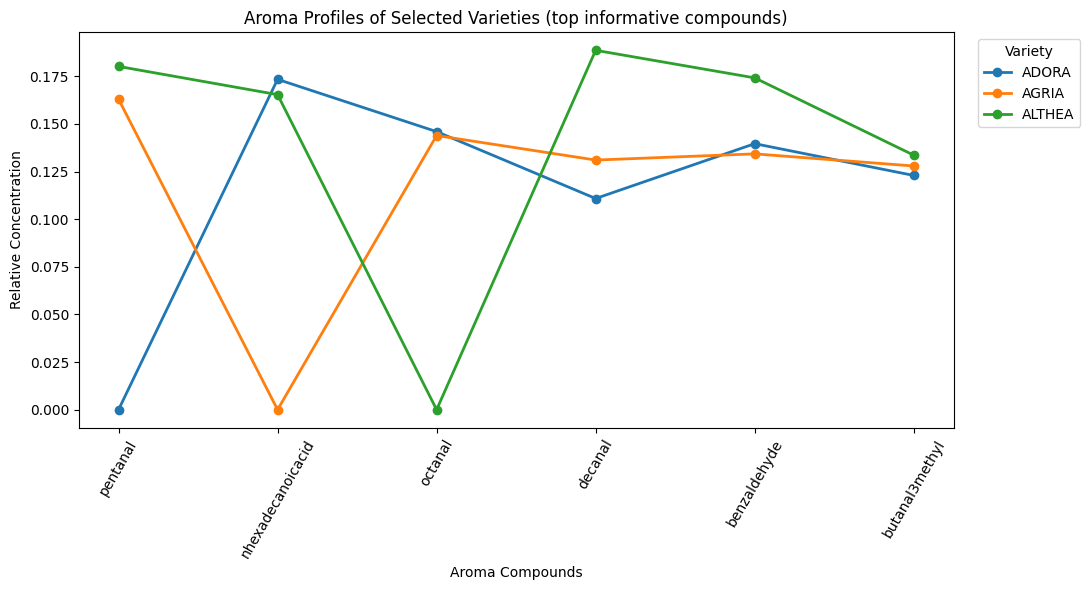

In [20]:
selected = ['ADORA','AGRIA','ALTHEA']
df = relative_conc.copy()
df.index = df.index.astype(str).str.upper()

# pick rows and drop siloxanes
rows = [v for v in map(str.upper, selected) if v in df.index]
X = df.loc[rows]
X = X.loc[:, ~X.columns.str.contains(r"siloxan|cyclotri|cyclotetra|cyclopenta", case=False)]

# keep compounds non-zero in at least 2 varieties, top 12 by variance
keep = (X.astype(bool).sum(axis=0) >= 2)
cols = X.loc[:, keep].var(axis=0).sort_values(ascending=False).head(12).index
X = X[cols]

# plot (one call, tidy legend)
ax = X.T.plot(figsize=(11,6), lw=2, marker='o')
ax.set_title("Aroma Profiles of Selected Varieties (top informative compounds)")
ax.set_xlabel("Aroma Compounds"); ax.set_ylabel("Relative Concentration")
ax.legend(title="Variety", bbox_to_anchor=(1.02,1), loc="upper left")
ax.tick_params(axis='x', labelrotation=60)
plt.tight_layout(); plt.show()


ALTHEA → stands out for high decanal and benzaldehyde (citrus/fruity), also high pentanal; octanal is near zero.

AGRIA → highest pentanal and strong octanal; almost no hexadecanoic acid.

ADORA → highest hexadecanoic acid; moderate benzaldehyde/octanal; very low pentanal.

Butanal, 3-methyl is similar across the three (small differences).

# joining the sensory panel data 

In [21]:
sensory = pd.read_excel(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\compound_analysis\Sensorial profiling SD 2005.xlsx")
print(sensory.columns)
sensory.head()

Index(['VARIETY', 'Variety_original', 'Unnamed: 2', 'Intensity of Skin Colour',
       'Thickness of skin', 'Speckles/Blemishes', 'Wrinkles', 'Dryness',
       'Skin Separation', 'Colour', 'Visible Ring', 'Patches/ Blemishes',
       'Waxy/ Shine', 'Floury/Flaky', 'Intensity of Aroma', 'Earthy Aroma',
       'Farmyard', 'Sweet', 'Starchy', 'Damp', 'Buttery', 'Fresh',
       'Intensity of Flavour', 'Potato Starch', 'Metallic Flavour',
       'Bitter Flavour', 'Earthy Flavour', 'Sour Flavour', 'Fresh Flavour',
       'Sweet Flavour', 'Root/ Vegetable Flavour',
       'Farmyard (grass/hay) flavour', 'Acidic', 'Dry Mouthfeel',
       'Waxy -Flesh', 'Mushy -Flesh', 'Crumbly - Flesh', 'Sticky - Flesh',
       'Soft - Flesh', 'Chewy - Skin', 'Thickness - Skin',
       'Starchy Aftertaste', 'Bitter Aftertaste', 'Drying Aftertaste',
       'Sour Aftertaste', 'Sweet Aftertaste', 'Metalic', 'Unnamed: 47',
       'cluster 1 Sp, cluster 3 UK', 'cluster 2 Sp, cluster 1 UK',
       'cluster 3 Sp, clu

,VARIETY,Variety_original,Unnamed: 2,Intensity of Skin Colour,Thickness of skin,Speckles/Blemishes,Wrinkles,Dryness,Skin Separation,Colour,...,Unnamed: 54,number ID,citric acid,Ras,Glucose mg/100 g FW,Fructose mg/100 g FW,Sucrose mg/100 g FW,Reducerende,% Reduc.,som
0,ADORA,ADORA,P1,47.229,23.958,44.438,12.667,40.521,20.188,20.708,...,NaN,1.0,88.2,Adora,249.3,175.5,46.5,424.8,90.133673,471.3
1,AGATA,AGATA,P2,30.604,18.896,41.417,13.125,33.5,25.229,37.167,...,NaN,2.0,89.7,Agata,437.0,296.8,158.6,733.8,82.227701,892.4
2,AGRIA,AGRIA,P3,61.187,33.875,32.333,10.229,50.979,29.708,64.583,...,NaN,3.0,37.8,Agria,19.3,7.0,51.3,26.3,33.891753,77.6
3,AMBRA,AMBRA,P4,43.667,21.354,28.458,10.333,36.729,20.479,53.417,...,NaN,4.0,38.2,Ambra,81.5,75.5,81.1,157.0,65.938681,238.1
4,AMPERA,AMPERA,P5,61.604,24.938,28.875,14.396,45.396,19.417,67.271,...,NaN,5.0,61.6,Ampera,178.1,130.6,105.6,308.7,74.511224,414.3


# Cleaning of sensory dataset 

In [22]:
# flavor-related columns
FLAVOR_COLS = [
    "Metallic Flavour","Bitter Flavour","Earthy Flavour","Sour Flavour",
    "Fresh Flavour","Sweet Flavour","Root/ Vegetable Flavour",
    "Farmyard (grass/hay) flavour","Bitter Aftertaste","Sour Aftertaste","Sweet Aftertaste"
]


sensory['VARIETY'] = sensory['VARIETY'].astype(str).str.strip()

# Drop any unnamed columns
sensory = sensory.drop(columns=[c for c in sensory.columns if str(c).startswith('Unnamed')], errors='ignore')

#  Coerce numerics & groupby mean per variety 
sensory_traits = sensory[FLAVOR_COLS].apply(pd.to_numeric, errors='coerce')
sensory_traits = sensory_traits.assign(VARIETY=sensory['VARIETY'])

sensory_summary = (
    sensory_traits
    .groupby('VARIETY', as_index=False)
    .mean(numeric_only=True)
)

print("Rows (varieties):", sensory_summary['VARIETY'].nunique())
print("Traits averaged:", len(FLAVOR_COLS))
print("First rows:")
print(sensory_summary.head())


Rows (varieties): 59
Traits averaged: 11
First rows:
  VARIETY  Metallic Flavour  Bitter Flavour  Earthy Flavour  Sour Flavour  \
0   ADORA            17.627          15.329          26.573        10.678   
1   AGATA            10.171          11.633          18.378         7.548   
2   AGRIA             8.018           5.872          20.421         3.787   
3   AMBRA            11.192          12.155          20.334         7.135   
4  AMPERA            13.018          11.176          20.486        11.591   

   Fresh Flavour  Sweet Flavour  Root/ Vegetable Flavour  \
0         24.014          3.098                   17.360   
1         30.340          3.250                   10.600   
2         29.188          1.859                   13.447   
3         33.122          2.729                   17.447   
4         24.644          3.511                   15.991   

   Farmyard (grass/hay) flavour  Bitter Aftertaste  Sour Aftertaste  \
0                        12.520             15.647  

# predicting the flavors for all the non existing varaieties by using the aroma compounds

In [23]:
aroma_df = aroma_pivot_renamed.reset_index()
aroma_df.rename(columns={'index': 'Variety'}, inplace=True)
sensory_summary.rename(columns={'VARIETY': 'Variety'}, inplace=True)

# Now both dataframes have 'Variety' column

# Clean whitespace 
for df in [aroma_df, sensory_summary]:
    df['Variety'] = df['Variety'].astype(str).str.strip().str.upper()

# Merge on 'Variety'
merged_aroma_sensory = pd.merge(aroma_df, sensory_summary, on='Variety', how='inner')

print(f"Number of merged varieties: {merged_aroma_sensory['Variety'].nunique()}")
print(merged_aroma_sensory.head())

merged_aroma_sensory.to_csv(r'C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\merged_aroma_sensory.csv', index=False)


Number of merged varieties: 20
     Variety  1-Nonanol (Floral, waxy)  \
0      ADORA                       0.0   
1      AGRIA                       0.0   
2     BERBER                       0.0   
3  BILDTSTAR                       0.0   
4     BINTJE                       0.0   

   2,3-Butanedione (Butter, creamy, sweet)  \
0                                      0.0   
1                                      0.0   
2                                      0.0   
3                                      0.0   
4                                      0.0   

   Benzaldehyde (Almond, cherry, fruity)  \
0                              17.984870   
1                              14.859493   
2                              15.354625   
3                              19.062354   
4                              13.831978   

   Butanal, 3-methyl- (Fruity, malty, chocolate)  \
0                                      15.836435   
1                                      14.154847   
2                 

Variety-Indexed Aroma–Sensory Data Alignment Pipeline

In [24]:
def ensure_variety_index(df):
    # Ensure DataFrame has 'Variety' as uppercase-stripped index.
    df = df.copy()
    if 'Variety' in df.columns:
        df = df.dropna(subset=['Variety']).set_index('Variety')
    else:
        cand = [c for c in df.columns if str(c).strip().lower() == 'variety']
        if cand:
            df = df.dropna(subset=[cand[0]]).set_index(cand[0])
    df.index = df.index.astype(str).str.strip().str.upper()
    df.index.name = 'Variety'
    return df

# Aroma features (compounds)
compound_matrix = ensure_variety_index(aroma_pivot_renamed)
compound_matrix.columns = [str(c).strip() for c in compound_matrix.columns]
compound_matrix = compound_matrix.apply(pd.to_numeric, errors="coerce")
compound_matrix = compound_matrix.loc[:, compound_matrix.notna().any(axis=0)]




predict all 94 varieties (raw + linear + isotonic) + LOOCV metrics

In [29]:

try:
    from IPython.display import display
except Exception:
    def display(x): print(x)

# X: aroma/compound features (Variety index) 
assert 'X' in globals(), "X (features) must be defined as a DataFrame with Variety index."
assert isinstance(X, pd.DataFrame)


#   compound_matrix: 94 x p DataFrame, Variety index
HAS_COMPOUND_MATRIX = 'compound_matrix' in globals() and isinstance(compound_matrix, pd.DataFrame)

# Helpers 
def canon_var(s: str) -> str:
    """Normalize variety names for consistent matching."""
    return re.sub(r"\s+", " ", str(s).strip().upper())

def norm_col(s: str) -> str:
    """Normalize sensory column headers for regex matching."""
    s = str(s).strip().lower().replace("flavour", "flavor")
    return re.sub(r"[^a-z0-9]+", "", s)

def rmse_metric(y_true, y_pred):
    """Backward-compatible RMSE for different sklearn versions."""
    try:
        return mean_squared_error(y_true, y_pred, squared=False)
    except TypeError:
        return np.sqrt(mean_squared_error(y_true, y_pred))

def make_pls(k=2):
    """Leak-free PLS pipeline (no double scaling)."""
    return Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("log", FunctionTransformer(np.log1p, validate=False)),
        ("sc",  StandardScaler()),
        ("pls", PLSRegression(n_components=k, scale=False)),
    ])

# Target (flavor) 
FLAVOR_COLS = [
    'Metallic Flavour','Bitter Flavour','Earthy Flavour','Sour Flavour',
    'Fresh Flavour','Sweet Flavour','Root/ Vegetable Flavour',
    'Farmyard (grass/hay) flavour','Bitter Aftertaste','Sour Aftertaste','Sweet Aftertaste'
]

CANON = {
    "Metallic Flavour":               [r"metallic"],
    "Bitter Flavour":                 [r"^bitter(?!aftertaste)"],
    "Earthy Flavour":                 [r"earthy|earthyaroma"],
    "Sour Flavour":                   [r"^sour(?!aftertaste)"],
    "Fresh Flavour":                  [r"fresh"],
    "Sweet Flavour":                  [r"^sweet(?!aftertaste)"],
    "Root/ Vegetable Flavour":        [r"root|vegetable"],
    "Farmyard (grass/hay) flavour":   [r"farmyard|grass|hay"],
    "Bitter Aftertaste":              [r"bitter.*aftertaste|aftertaste.*bitter"],
    "Sour Aftertaste":                [r"sour.*aftertaste|aftertaste.*sour"],
    "Sweet Aftertaste":               [r"sweet.*aftertaste|aftertaste.*sweet"],
}

#  Load flavor panel (20 labeled) and build df0 
SENSORY_PATHS = [
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\compound_analysis\Sensorial profiling SD 2005.xlsx"
]
sensory = None
for p in SENSORY_PATHS:
    if os.path.exists(p):
        sensory = pd.read_excel(p)
        print("Loaded sensory:", p)
        break
if sensory is None:
    raise FileNotFoundError("Update SENSORY_PATHS to the correct sensory file.")

# Find variety column
var_candidates = [c for c in sensory.columns if str(c).strip().upper() in
                  {"VARIETY","VARIETIES","SAMPLE","SAMPLE NAME","SAMPLENAME","VARIETY NAME"}]
if not var_candidates:
    raise RuntimeError("Could not find Variety column in sensory file.")
var_col = var_candidates[0]

# Map messy headers -> canonical names
sens_cols = [c for c in sensory.columns if c != var_col]
nmap = {c: norm_col(c) for c in sens_cols}
colmap = {}  # original col -> canonical name (first match per canonical key)
for canon_name, pats in CANON.items():
    for c in sens_cols:
        nc = nmap[c]
        if all(re.search(p, nc) is not None for p in pats):
            colmap[c] = canon_name
            break

# Keep only mapped columns and coerce numeric
keep = [var_col] + list(colmap.keys())
df0 = sensory[keep].copy().rename(columns={var_col: "Variety", **colmap})
df0["Variety"] = df0["Variety"].map(canon_var)

for c in colmap.values():
    if c in df0.columns:
        df0[c] = (df0[c].astype(str)
                        .str.replace(",", ".", regex=False)
                        .str.replace(r"[^\d\.\-eE]+", "", regex=True))
        df0[c] = pd.to_numeric(df0[c], errors="coerce")

# Average replicates
df0 = df0.groupby("Variety", as_index=True).mean(numeric_only=True)

targets = [t for t in FLAVOR_COLS if t in df0.columns]
missing = [t for t in FLAVOR_COLS if t not in df0.columns]
print("Targets to model:", targets)
if missing:
    print("Missing (not numeric / not found):", missing)

#  Build a guaranteed full feature matrix (should be ~94 rows) 
if HAS_COMPOUND_MATRIX:
    X_all = compound_matrix.copy()
else:
    X_all = X.copy()
X_all.index = X_all.index.map(canon_var)

# Optional: drop columns that are entirely NA
X_all = X_all.loc[:, X_all.notna().any(axis=0)]

# Sanity checks
n_all = len(X_all)
n_lab = len(df0.index)
n_inter = len(X_all.index.intersection(df0.index))
print(f"[CHECK] X_all rows (expect ~94): {n_all}")
print(f"[CHECK] Labeled in df0 (expect ~20): {n_lab}")
print(f"[CHECK] Intersection used for training: {n_inter}")
assert n_all >= 80, "X_all looks too small — did you align X to df0 earlier?"
assert n_lab >= 15, "Too few labeled rows to train reliably."

# Train per target, LOOCV metrics, calibration 
DO_LINEAR_CAL = True   # also save linear-calibrated columns 
K_PLS = 2              # fixed k

pred_cols, cal_cols, lin_cols = {}, {}, {}
metrics_rows = []

for tgt in targets:
    y = df0[tgt].dropna()
    if y.empty:
        continue

    # Train only on labeled intersection (20)
    train_idx = X_all.index.intersection(y.index)
    if len(train_idx) < 3:
        print(f"Skip {tgt}: too few labeled varieties ({len(train_idx)}).")
        continue

    X_lab = X_all.loc[train_idx]
    y_lab = y.loc[train_idx].astype(float)

    # Fit PLS (k=2)
    pipe = make_pls(k=K_PLS).fit(X_lab, y_lab)

    # Predict for ALL varieties (raw)
    raw_all = pipe.predict(X_all).ravel()
    pred_cols[f"{tgt}__pred"] = raw_all

    # LOOCV predictions on labeled set
    yhat_cv = cross_val_predict(
        make_pls(k=K_PLS), X_lab, y_lab, cv=LeaveOneOut(), n_jobs=-1, method="predict"
    ).ravel()

    # Metrics
    rho,  _ = spearmanr(y_lab.values, yhat_cv)
    pr,   _ = pearsonr(y_lab.values, yhat_cv)
    r2       = r2_score(y_lab.values, yhat_cv)
    mae      = mean_absolute_error(y_lab.values, yhat_cv)
    rmse     = rmse_metric(y_lab.values, yhat_cv)

    # Linear calibration: y ≈ a + b*yhat (on labeled LOOCV preds)
    A = np.vstack([np.ones_like(yhat_cv), yhat_cv]).T
    a, b = np.linalg.lstsq(A, y_lab.values, rcond=None)[0]

    if DO_LINEAR_CAL and np.isfinite(a) and np.isfinite(b):
        lin_cols[f"{tgt}__pred_lin"] = a + b * raw_all

    # Isotonic calibration (on labeled LOOCV preds) if enough labels
    if len(y_lab) >= 6:
        iso = IsotonicRegression(out_of_bounds='clip').fit(yhat_cv, y_lab.values)
        cal_cols[f"{tgt}__pred_cal"] = iso.transform(raw_all)

    # Store metrics
    metrics_rows.append({
        "target": tgt,
        "n_labels": int(len(y_lab)),
        "R2_cv": float(r2),
        "Spearman_cv": float(rho) if not np.isnan(rho) else np.nan,
        "Pearson_cv": float(pr) if not np.isnan(pr) else np.nan,
        "MAE_cv": float(mae),
        "RMSE_cv": float(rmse),
        "Cal_intercept": float(a),
        "Cal_slope": float(b),
    })


OUTPUT_DIR = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Evaluation summary
cv_summary = pd.DataFrame(metrics_rows).sort_values("R2_cv", ascending=False)
cv_summary_path = os.path.join(OUTPUT_DIR, "plsr_loocv_eval_summary.csv")
cv_summary.to_csv(cv_summary_path, index=False)
print(f"Saved: {cv_summary_path}")

# Predictions for ALL 94 (raw + isotonic + linear if available)
pred_all = pd.DataFrame(index=X_all.index, data={**pred_cols, **cal_cols, **lin_cols}) \
            .reset_index().rename(columns={"index": "Variety"})
pred_all_path = os.path.join(OUTPUT_DIR, "rankfirst_predictions_all_varieties_CALIBRATED.csv")
pred_all.to_csv(pred_all_path, index=False)

# Unlabeled-only predictions (should be ~74)
labeled_set = set(df0.index)
pred_unlabeled = pred_all[~pred_all['Variety'].isin(labeled_set)].copy()
pred_unlabeled_path = os.path.join(OUTPUT_DIR, "flavor_predictions_unlabeled_74.csv")
pred_unlabeled.to_csv(pred_unlabeled_path, index=False)

# Final shape checks
print("pred_all  :", pred_all.shape)
print("pred_unlabeled shape :", pred_unlabeled.shape)
assert pred_all.shape[0] >= 80, "pred_all has too few rows — something trimmed the varieties."

# Quick peek
display(cv_summary.head(10))
display(pred_all.head())
pred_all.columns

Loaded sensory: C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\compound_analysis\Sensorial profiling SD 2005.xlsx
Targets to model: ['Metallic Flavour', 'Bitter Flavour', 'Earthy Flavour', 'Sour Flavour', 'Fresh Flavour', 'Sweet Flavour', 'Root/ Vegetable Flavour', 'Farmyard (grass/hay) flavour', 'Bitter Aftertaste', 'Sour Aftertaste', 'Sweet Aftertaste']
[CHECK] X_all rows (expect ~94): 94
[CHECK] Labeled in df0 (expect ~20): 59
[CHECK] Intersection used for training: 20
Saved: C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\plsr_loocv_eval_summary.csv
pred_all  : (94, 34)
pred_unlabeled shape : (74, 34)


,target,n_labels,R2_cv,Spearman_cv,Pearson_cv,MAE_cv,RMSE_cv,Cal_intercept,Cal_slope
9,Sour Aftertaste,20,-0.257495,0.293233,0.178103,1.638119,2.298597,5.406266,0.248816
1,Bitter Flavour,20,-0.360390,0.170741,0.062168,1.982239,2.745652,6.918011,0.093407
10,Sweet Aftertaste,20,-0.410414,0.097744,0.050645,1.659006,2.100725,2.940576,0.073168
6,Root/ Vegetable Flavour,20,-0.436528,0.203008,0.220352,2.080511,2.594934,9.657968,0.241888
2,Earthy Flavour,20,-0.478546,0.239098,0.097609,3.658531,4.531268,15.061130,0.123081
8,Bitter Aftertaste,20,-0.528085,0.234675,0.089783,1.958187,2.866634,6.941297,0.110185
3,Sour Flavour,20,-0.861148,-0.175940,-0.313969,2.100671,2.670502,9.525213,-0.478198
5,Sweet Flavour,20,-1.019148,-0.073684,-0.124544,2.251851,3.012693,5.307411,-0.141837
4,Fresh Flavour,20,-1.279547,-0.112782,-0.119942,3.741822,5.043861,35.123646,-0.119300
0,Metallic Flavour,20,-1.735369,-0.206015,0.036075,3.655006,4.674362,8.607692,0.026920


,Variety,Metallic Flavour__pred,Bitter Flavour__pred,Earthy Flavour__pred,Sour Flavour__pred,Fresh Flavour__pred,Sweet Flavour__pred,Root/ Vegetable Flavour__pred,Farmyard (grass/hay) flavour__pred,Bitter Aftertaste__pred,...,Bitter Flavour__pred_lin,Earthy Flavour__pred_lin,Sour Flavour__pred_lin,Fresh Flavour__pred_lin,Sweet Flavour__pred_lin,Root/ Vegetable Flavour__pred_lin,Farmyard (grass/hay) flavour__pred_lin,Bitter Aftertaste__pred_lin,Sour Aftertaste__pred_lin,Sweet Aftertaste__pred_lin
0,ADORA,11.636453,10.108955,19.482391,8.368302,27.786171,3.202543,14.634439,16.926552,10.222981,...,7.862255,17.459044,5.523512,31.808752,4.853171,13.197864,13.838047,8.067712,7.835167,3.084403
1,AGRIA,9.449617,7.268194,21.718954,5.989872,31.174038,2.845011,11.531693,13.799052,8.758126,...,7.596909,17.734322,6.660871,31.404579,4.903883,12.447347,14.178856,7.906308,6.796900,3.033925
2,ALOUETTE,9.482931,7.913505,16.023694,6.535103,32.396867,5.890552,12.617123,13.460228,8.058723,...,7.657185,17.033344,6.400143,31.258695,4.471912,12.709900,14.215778,7.829244,7.199740,3.117696
3,ALTHEA,10.304472,7.928378,22.587698,6.759576,25.543686,-1.302240,11.214780,14.855057,9.793660,...,7.658574,17.841248,6.292800,32.076281,5.492117,12.370690,14.063781,8.020408,7.248337,3.057748
4,ALTURAS,7.056032,5.849518,14.175909,5.487073,31.859335,4.248430,10.869337,12.466034,6.227299,...,7.464395,16.805916,6.901308,31.322823,4.704826,12.287131,14.324117,7.627450,7.059270,3.270196


Index(['Variety', 'Metallic Flavour__pred', 'Bitter Flavour__pred',
       'Earthy Flavour__pred', 'Sour Flavour__pred', 'Fresh Flavour__pred',
       'Sweet Flavour__pred', 'Root/ Vegetable Flavour__pred',
       'Farmyard (grass/hay) flavour__pred', 'Bitter Aftertaste__pred',
       'Sour Aftertaste__pred', 'Sweet Aftertaste__pred',
       'Metallic Flavour__pred_cal', 'Bitter Flavour__pred_cal',
       'Earthy Flavour__pred_cal', 'Sour Flavour__pred_cal',
       'Fresh Flavour__pred_cal', 'Sweet Flavour__pred_cal',
       'Root/ Vegetable Flavour__pred_cal',
       'Farmyard (grass/hay) flavour__pred_cal', 'Bitter Aftertaste__pred_cal',
       'Sour Aftertaste__pred_cal', 'Sweet Aftertaste__pred_cal',
       'Metallic Flavour__pred_lin', 'Bitter Flavour__pred_lin',
       'Earthy Flavour__pred_lin', 'Sour Flavour__pred_lin',
       'Fresh Flavour__pred_lin', 'Sweet Flavour__pred_lin',
       'Root/ Vegetable Flavour__pred_lin',
       'Farmyard (grass/hay) flavour__pred_lin', 'Bitte

In [26]:


OUT_DIR = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\analysis_94"
PRED_CANDIDATES = [
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\rankfirst_predictions_all_varieties_CALIBRATED.csv",
    
]

# Canonical flavor names 
FLAVOR_COLS = [
    'Metallic Flavour','Bitter Flavour','Earthy Flavour','Sour Flavour',
    'Fresh Flavour','Sweet Flavour','Root/ Vegetable Flavour',
    'Farmyard (grass/hay) flavour','Bitter Aftertaste','Sour Aftertaste','Sweet Aftertaste'
]

os.makedirs(OUT_DIR, exist_ok=True)

# Load  94-row predictions file
pred = None; used_path = None
for p in PRED_CANDIDATES:
    if os.path.exists(p):
        df = pd.read_csv(p)
        if "Variety" in df.columns and df.shape[0] >= 80:
            pred = df.copy()
            used_path = p
            break

assert pred is not None, "No 94-row predictions file found. Use any of the candidate paths or re-run the 94-var prediction cell to create one."

print("Using predictions file:", used_path, pred.shape)


use_cols = {}
suffix_style = any("__pred" in c for c in pred.columns)

if suffix_style:
    # prefer calibrated > linear > raw
    flavors = sorted({c.split("__")[0] for c in pred.columns if "__pred" in c})
    for f in flavors:
        if f"{f}__pred_cal" in pred.columns:
            use_cols[f] = f"{f}__pred_cal"
        elif f"{f}__pred_lin" in pred.columns:
            use_cols[f] = f"{f}__pred_lin"
        else:
            use_cols[f] = f"{f}__pred"
else:
    # plain flavor columns
    flavors = [f for f in FLAVOR_COLS if f in pred.columns]
    for f in flavors:
        use_cols[f] = f

# sanity
assert "Variety" in pred.columns, "Predictions must contain a 'Variety' column."
assert len(use_cols) >= 2, "Could not find enough flavor columns in the predictions file."

print("Flavors found:", list(use_cols.keys()))

# Build wide matrix Variety×Flavor (numeric) 
M = pred[["Variety"] + list(use_cols.values())].copy()
M = M.rename(columns={v:k for k,v in use_cols.items()})
M = M.set_index("Variety")
M = M.apply(pd.to_numeric, errors="coerce")

# Percentiles & z-scores across the 94 varieties 
Pct = M.rank(pct=True) * 100.0
Z   = (M - M.mean()) / M.std(ddof=0)
Z   = Z.replace([np.inf, -np.inf], np.nan).fillna(0.0)

pct_path = os.path.join(OUT_DIR, "Flavor_Perc_All94.csv")
z_path   = os.path.join(OUT_DIR, "Flavor_Z_All94.csv")
M_path   = os.path.join(OUT_DIR, "Flavor_ChosenSignal_All94.csv")
Pct.to_csv(pct_path)
Z.to_csv(z_path)
M.to_csv(M_path)
print("Saved:")
print(" -", pct_path)
print(" -", z_path)
print(" -", M_path)


Using predictions file: C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\rankfirst_predictions_all_varieties_CALIBRATED.csv (94, 34)
Flavors found: ['Bitter Aftertaste', 'Bitter Flavour', 'Earthy Flavour', 'Farmyard (grass/hay) flavour', 'Fresh Flavour', 'Metallic Flavour', 'Root/ Vegetable Flavour', 'Sour Aftertaste', 'Sour Flavour', 'Sweet Aftertaste', 'Sweet Flavour']
Saved:
 - C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\analysis_94\Flavor_Perc_All94.csv
 - C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\analysis_94\Flavor_Z_All94.csv
 - C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\analysis_94\Flavor_ChosenSignal_All94.csv


In [27]:

from pathlib import Path

BASE = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\analysis_94"
Z_path   = os.path.join(BASE, "Flavor_Z_All94.csv")
Pct_path = os.path.join(BASE, "Flavor_Perc_All94.csv")
Sig_path = os.path.join(BASE, "Flavor_ChosenSignal_All94.csv")

Z   = pd.read_csv(Z_path, index_col=0)
Pct = pd.read_csv(Pct_path, index_col=0)
Sig = pd.read_csv(Sig_path, index_col=0)

print("Z shape:", Z.shape)
print("NaNs per column (Z):")
print(Z.isna().sum().sort_values(ascending=False))

# Drop all-empty columns (should be none) and flag near-zero variance (just in case)
keep_cols = [c for c in Z.columns if Z[c].notna().any()]
Z = Z[keep_cols].copy()
nzv = Z.std(ddof=0)
print("\nNear-zero variance columns (std<1e-6):", nzv[nzv < 1e-6].index.tolist())


Z shape: (94, 11)
NaNs per column (Z):
Bitter Aftertaste               0
Bitter Flavour                  0
Earthy Flavour                  0
Farmyard (grass/hay) flavour    0
Fresh Flavour                   0
Metallic Flavour                0
Root/ Vegetable Flavour         0
Sour Aftertaste                 0
Sour Flavour                    0
Sweet Aftertaste                0
Sweet Flavour                   0
dtype: int64

Near-zero variance columns (std<1e-6): []


PCA of Predicted Flavour Profiles (94 Varieties)

Explained variance (first 5 PCs): [0.567 0.12  0.091 0.08  0.045]


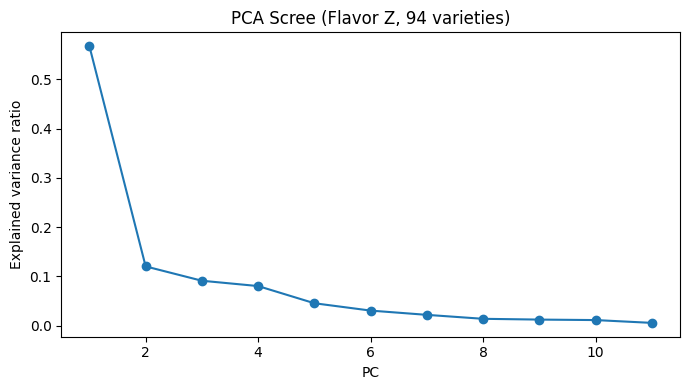

NameError: name 'Zc' is not defined

In [28]:


# Fit PCA
pca = PCA().fit(Z.values)
expl = pca.explained_variance_ratio_
print("Explained variance (first 5 PCs):", np.round(expl[:5], 3))

plt.figure(figsize=(7,4))
plt.plot(np.arange(1, len(expl)+1), expl, marker="o")
plt.title("PCA Scree (Flavor Z, 94 varieties)")
plt.xlabel("PC")
plt.ylabel("Explained variance ratio")
plt.tight_layout()
plt.show()

# Scores (PC1 vs PC2)
scores = pca.transform(Z.values)
PC = pd.DataFrame(scores[:, :5], index=Zc.index, columns=[f"PC{i}" for i in range(1,6)])

plt.figure(figsize=(6,5))
plt.scatter(PC["PC1"], PC["PC2"])
for v, x, y in zip(PC.index, PC["PC1"], PC["PC2"]):
    plt.annotate(v, (x,y), fontsize=7, xytext=(3,3), textcoords="offset points")
plt.axhline(0, ls="--", lw=0.5); plt.axvline(0, ls="--", lw=0.5)
plt.title("PCA scores (PC1 vs PC2) — 94 varieties")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout()
plt.show()

# Loadings
loadings = pd.DataFrame(pca.components_.T, index=Zc.columns, columns=[f"PC{i}" for i in range(1, len(expl)+1)])



the curve shows a clear “elbow” after the first two components, indicating that 2–3 PCs summarize most of the structure while additional PCs add only small incremental variance.

The spread along PC1 and PC2 indicates meaningful differentiation among varieties in multivariate flavor space; no single tight cluster dominates, suggesting a continuum of flavor profiles rather than discrete groups.

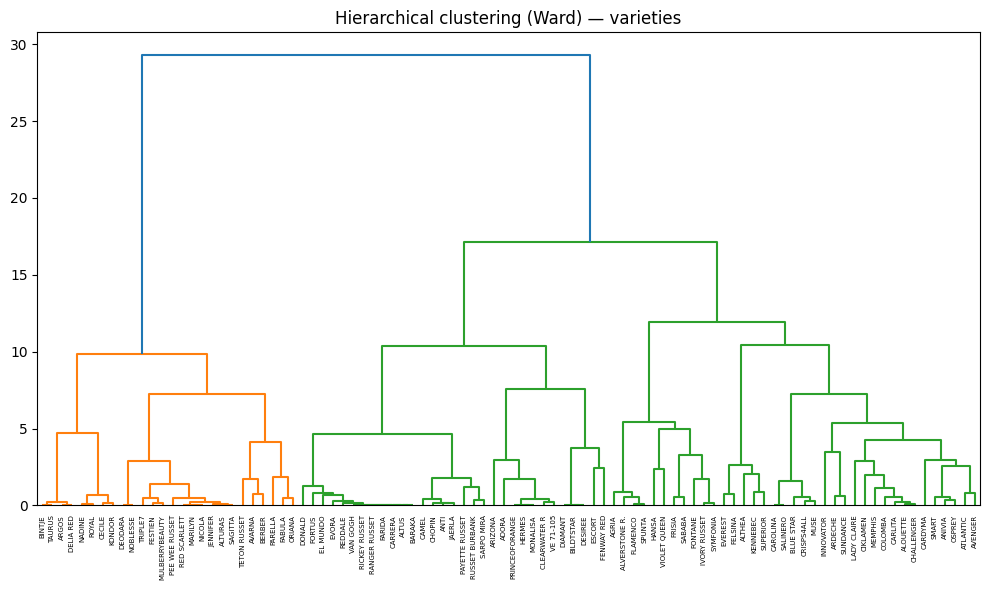

In [ ]:


# Hierarchical clustering on varieties
L = linkage(Z.values, method="ward", metric="euclidean")

plt.figure(figsize=(10, 6))
dendrogram(L, labels=Z.index.tolist(), leaf_rotation=90)
plt.title("Hierarchical clustering (Ward) — varieties")
plt.tight_layout()
plt.show()

# Choose a cluster cut () K=3 or by distance)
K = 3
labels = fcluster(L, K, criterion="maxclust")
clusters = pd.DataFrame({"Variety": Z.index, "cluster": labels}).set_index("Variety")


In [ ]:


#  Load Z (standardized flavor matrix: 94 x 11
ANALYSIS_DIR = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\analysis_94"
if 'Z' in globals() and isinstance(Z, pd.DataFrame) and Z.shape[0] >= 80:
    Z_use = Z.copy()
else:
    Z_use = pd.read_csv(os.path.join(ANALYSIS_DIR, "Flavor_Z_All94.csv"), index_col=0)



# Ward linkage on full 11-D space
L = linkage(Z_use.values, method="ward")

# Choose number of clusters by silhouette on k=2..6
best_k, best_s = None, -1
sils = {}
for k in range(2, 7):
    labels_k = fcluster(L, t=k, criterion="maxclust")
    s = silhouette_score(Z_use.values, labels_k, metric="euclidean")
    sils[k] = s
    if s > best_s:
        best_k, best_s = k, s

print("Silhouette by k:", {k: round(v, 3) for k, v in sils.items()})
print(f"Chosen k = {best_k} (silhouette = {best_s:.3f})")

#  Final labels
labels = fcluster(L, t=best_k, criterion="maxclust")
clusters = pd.DataFrame({"Variety": Z_use.index, "cluster": labels}).set_index("Variety")
display(clusters.head(10))

#  Per-cluster flavor means in percentiles
# Percentiles are rank-based, so computing them on Z or raw gives the same ordering.
Pct = Z_use.rank(pct=True) * 100.0
cluster_means = Pct.join(clusters).groupby("cluster").mean().round(1)
display(cluster_means)




Silhouette by k: {2: np.float64(0.402), 3: np.float64(0.311), 4: np.float64(0.309), 5: np.float64(0.333), 6: np.float64(0.369)}
Chosen k = 2 (silhouette = 0.402)


,cluster
Variety,
ADORA,2
AGRIA,2
ALOUETTE,2
ALTHEA,2
ALTURAS,1
ALTUS,2
ALVERSTONE R.,2
ANIVIA,2
ANTI,2


,Bitter Aftertaste,Bitter Flavour,Earthy Flavour,Farmyard (grass/hay) flavour,Fresh Flavour,Metallic Flavour,Root/ Vegetable Flavour,Sour Aftertaste,Sour Flavour,Sweet Aftertaste,Sweet Flavour
cluster,,,,,,,,,,,
1,15.1,20.2,16.5,27.9,63.3,18.5,33.2,28.2,29.3,83.2,68.8
2,64.1,62.1,63.5,59.2,45.6,62.8,57.2,59.1,58.7,38.0,43.5


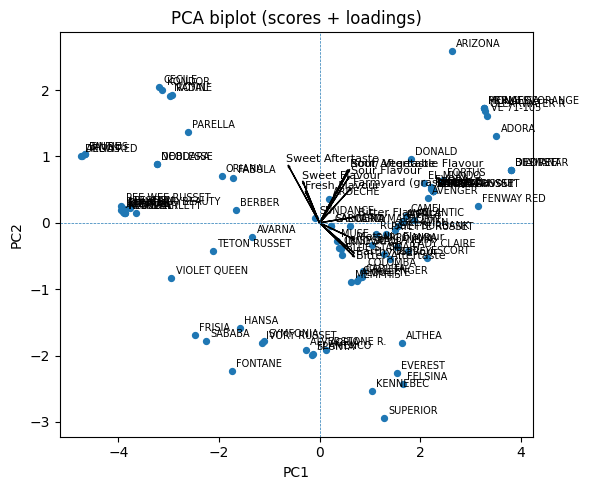

In [ ]:
# Scores (PC1 vs PC2)
scores = pca.transform(Z.values)
PC = pd.DataFrame(scores[:, :5], index=Z.index, columns=[f"PC{i}" for i in range(1,6)])

# Loadings
loadings = pd.DataFrame(
    pca.components_.T, index=Z.columns, columns=[f"PC{i}" for i in range(1, len(expl)+1)]
)
plt.figure(figsize=(6,5))
plt.scatter(PC["PC1"], PC["PC2"], s=18)
for v, x, y in zip(PC.index, PC["PC1"], PC["PC2"]):
    plt.annotate(v, (x,y), fontsize=7, xytext=(3,3), textcoords="offset points")
# arrows for loadings (scaled to fit)
scale = 2.0
for f in loadings.index:
    x, y = loadings.loc[f,"PC1"]*scale, loadings.loc[f,"PC2"]*scale
    plt.arrow(0,0,x,y, head_width=0.03, length_includes_head=True)
    plt.text(x*1.05, y*1.05, f, fontsize=8)
plt.axhline(0, ls="--", lw=0.5); plt.axvline(0, ls="--", lw=0.5)
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title("PCA biplot (scores + loadings)")
plt.tight_layout(); plt.show()


Best k = 2 (silhouette 0.402): clear but moderate separation.

Cluster 1: low Bitter/Earthy/Metallic/Sour; high Fresh & Sweet → “sweet–fresh, few off-notes.”

Cluster 2: higher Bitter/Earthy/Metallic/Sour; lower Fresh & Sweet → “savoury/earthy–bitter.”

Ward dendrogram sees this split in full 11D; PC1–PC2 can hide it.

In [ ]:

sizes = clusters['cluster'].value_counts().sort_index()
print("Cluster sizes:", sizes.to_dict())

# Peek at a few names per cluster
for c in sorted(clusters['cluster'].unique()):
    names = clusters[clusters['cluster']==c].index.tolist()[:12]
    print(f"\nCluster {c} examples ({len(names)} shown):")
    print(", ".join(names))


Cluster sizes: {1: 26, 2: 68}

Cluster 1 examples (12 shown):
ALTURAS, ARGOS, AVARNA, BERBER, BINTJE, CECILE, DELIA RED, DEODARA, FABULA, FESTIEN, JENNIFER, KONDOR

Cluster 2 examples (12 shown):
ADORA, AGRIA, ALOUETTE, ALTHEA, ALTUS, ALVERSTONE R., ANIVIA, ANTI, ARDECHE, ARIZONA, ATLANTIC, AVENGER


Heatmap of cluster means (percentiles)

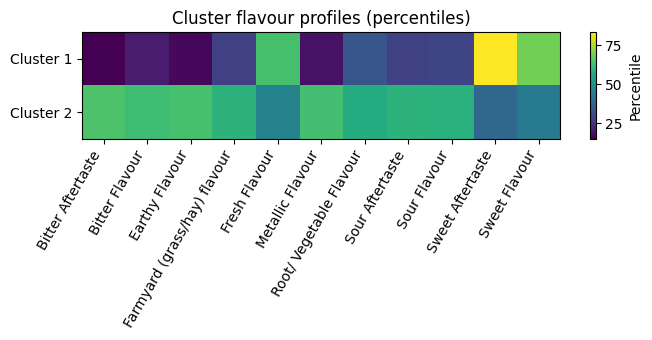

In [ ]:

cm = cluster_means.copy() 
plt.figure(figsize=(7,3.5))
im = plt.imshow(cm.values, aspect='auto')
plt.yticks(range(len(cm.index)), [f"Cluster {i}" for i in cm.index])
plt.xticks(range(cm.shape[1]), cm.columns, rotation=60, ha='right')
plt.colorbar(im, label='Percentile')
plt.title('Cluster flavour profiles (percentiles)')
plt.tight_layout(); plt.show()


Cluster 1 (top row): very low Bitter/Earthy/Metallic/Sour percentiles, high Fresh & especially Sweet Aftertaste → “sweet–fresh, low off-notes.”

Cluster 2 (bottom row): higher Bitter/Earthy/Metallic/Sour, lower Sweet/Fresh → “savoury/earthy–bitter.”

Which flavours drive the split the most

In [ ]:
diff = (cluster_means.loc[2] - cluster_means.loc[1]).sort_values(ascending=False)
print("Cluster2 – Cluster1 percentile differences:\n", diff)


Cluster2 – Cluster1 percentile differences:
 Bitter Aftertaste               49.0
Earthy Flavour                  47.0
Metallic Flavour                44.3
Bitter Flavour                  41.9
Farmyard (grass/hay) flavour    31.3
Sour Aftertaste                 30.9
Sour Flavour                    29.4
Root/ Vegetable Flavour         24.0
Fresh Flavour                  -17.7
Sweet Flavour                  -25.3
Sweet Aftertaste               -45.2
dtype: float64


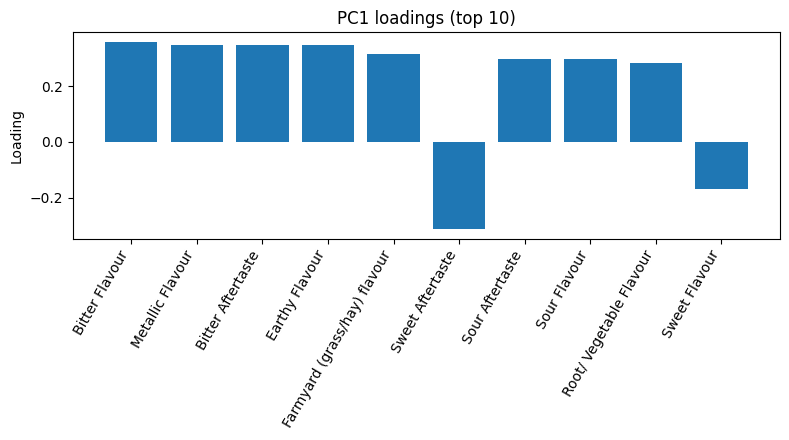

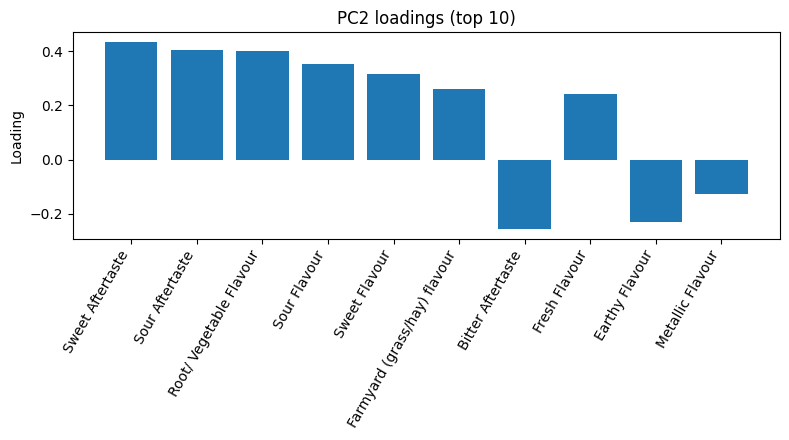

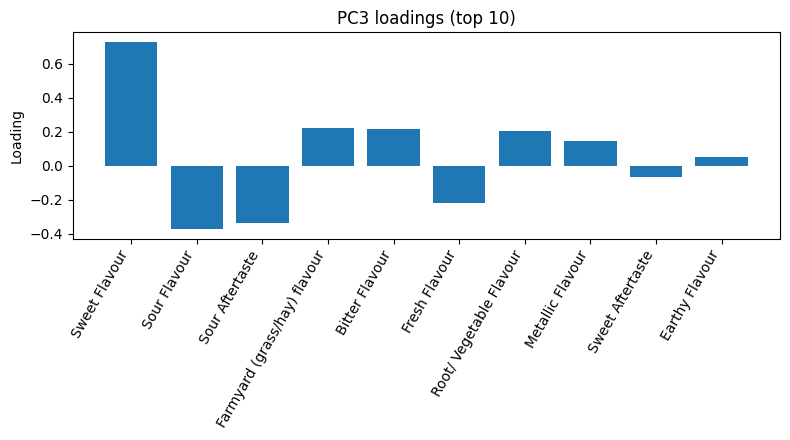

In [ ]:


def plot_pc_loadings(loadings, pc="PC1", top=10):
    s = loadings[pc].copy()
    s = s.reindex(s.abs().sort_values(ascending=False).index)  # sort by |loading|
    if top: s = s.iloc[:top]
    plt.figure(figsize=(8,4.5))
    plt.bar(range(len(s)), s.values)
    plt.xticks(range(len(s)), s.index, rotation=60, ha="right")
    plt.ylabel("Loading"); plt.title(f"{pc} loadings (top {len(s)})")
    plt.tight_layout(); plt.show()

for pc in ["PC1","PC2","PC3"]:
    if pc in loadings.columns: plot_pc_loadings(loadings, pc, top=10)


PC1 (main axis): + Bitter, Metallic, Earthy, Farmyard, Sour → “off-notes/savoury”; – Sweet Aftertaste (and a bit Sweet Flavour).
⇒ High PC1 = stronger off-notes; Low PC1 = sweeter/cleaner.

PC2: + Sweet Aftertaste, Sour Aftertaste, Root/Vegetable, Sour Flavour; – Bitter Aftertaste, Earthy, Metallic, Fresh.
⇒ Separates aftertaste/sour profile from earthy–metallic/fresh.

PC3: + Sweet Flavour (strong), + Sour Flavour; – Sour Aftertaste.

prince version: 0.13.0


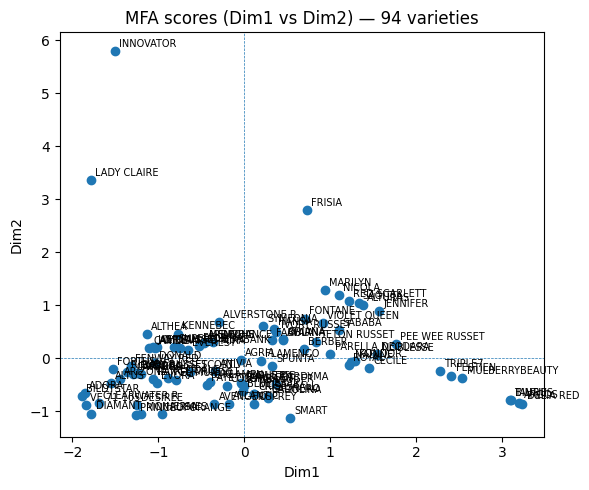

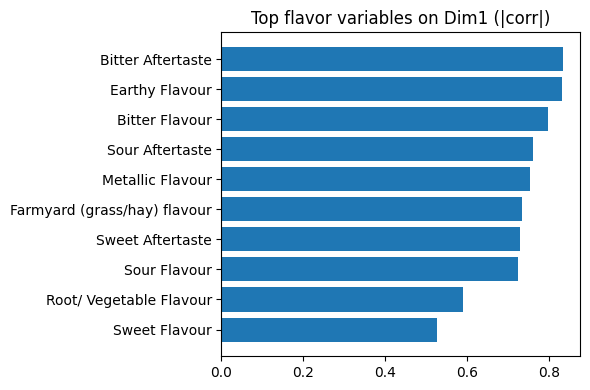

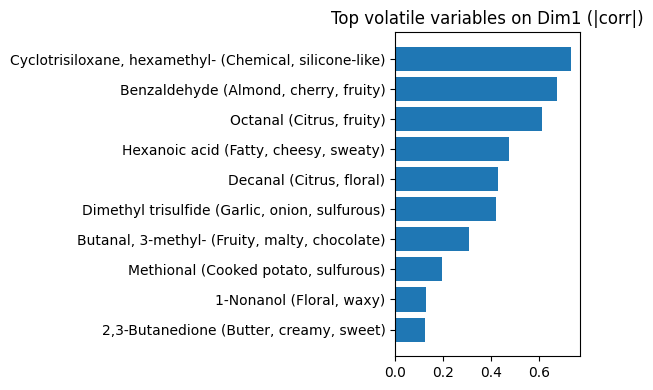

Saved: MFA_row_scores.csv, MFA_variable_correlations.csv


In [ ]:
#  MFA on 94 varieties: FLAVORS (Z) + VOLATILES (compound_matrix or X) 

import prince

# Expect: Z = (94 x 11) flavor matrix with Variety index (percentiles or z)
assert 'Z' in globals(), "Need Z (flavor matrix, 94x11) in memory."
X_vol_94 = (compound_matrix if 'compound_matrix' in globals() else X).copy()

# Align varieties and clean
Z_flav_94 = Z.copy()
common = Z_flav_94.index.intersection(X_vol_94.index)
Z_flav_94 = Z_flav_94.loc[common]
X_vol_94  = X_vol_94.loc[common]

# Keep only non-empty columns; fill remaining NaNs
Z_flav_94 = Z_flav_94.loc[:, Z_flav_94.notna().any(axis=0)].apply(pd.to_numeric, errors="coerce").fillna(0.0)
X_vol_94  = X_vol_94.loc[:, X_vol_94.notna().any(axis=0)].apply(pd.to_numeric, errors="coerce").fillna(0.0)

FLAV_GROUP = list(Z_flav_94.columns)
VOL_GROUP  = list(X_vol_94.columns)

# Build input matrix and groups as a DICT (required by prince 0.13.0)
df_mfa = pd.concat([Z_flav_94, X_vol_94], axis=1)
groups_dict = {
    "FLAVORS": FLAV_GROUP,
    "VOLATILES": VOL_GROUP,
}

# Fit MFA (groups passed to .fit as dict)
print("prince version:", prince.__version__)
mfa = prince.MFA(n_components=5, n_iter=5, random_state=42)
mfa = mfa.fit(df_mfa, groups=groups_dict)

# Row scores (varieties)
row_coords = mfa.row_coordinates(df_mfa)      # shape: (94, 5)

# Column–dimension correlations (API or manual fallback)
try:
    col_corr = mfa.column_correlations(df_mfa)    # if available
except Exception:
    # Manual Pearson corr of standardized variables vs scores
    S = row_coords.copy()
    S = (S - S.mean(0)) / S.std(0, ddof=0).replace(0, 1)
    Xc = (df_mfa - df_mfa.mean(0)) / df_mfa.std(0, ddof=0).replace(0, 1)
    out = {}
    for k in range(S.shape[1]):
        out[f"Dim{k+1}"] = Xc.apply(lambda s: np.corrcoef(s.values, S.iloc[:, k].values)[0, 1])
    col_corr = pd.DataFrame(out)

expl = getattr(mfa, "explained_inertia_", None)
if expl is not None:
    plt.figure(figsize=(6,3))
    plt.plot(np.arange(1, len(expl)+1), expl, marker="o")
    plt.title("MFA Scree (explained inertia)")
    plt.xlabel("Dimension"); plt.ylabel("Inertia ratio")
    plt.tight_layout(); plt.show()

plt.figure(figsize=(6,5))
plt.scatter(row_coords[0], row_coords[1])
for v, x, y in zip(row_coords.index, row_coords[0], row_coords[1]):
    plt.annotate(v, (x,y), fontsize=7, xytext=(3,3), textcoords="offset points")
plt.axhline(0, ls="--", lw=0.5); plt.axvline(0, ls="--", lw=0.5)
plt.title("MFA scores (Dim1 vs Dim2) — 94 varieties")
plt.xlabel("Dim1"); plt.ylabel("Dim2")
plt.tight_layout(); plt.show()

# Top contributors on Dim1
flav_corr = col_corr.loc[FLAV_GROUP, "Dim1"].abs().sort_values(ascending=False).head(10)
plt.figure(figsize=(6,4)); plt.barh(flav_corr.index, flav_corr.values); plt.gca().invert_yaxis()
plt.title("Top flavor variables on Dim1 (|corr|)"); plt.tight_layout(); plt.show()

vol_corr = col_corr.loc[VOL_GROUP, "Dim1"].abs().sort_values(ascending=False).head(10)
plt.figure(figsize=(6,4)); plt.barh(vol_corr.index, vol_corr.values); plt.gca().invert_yaxis()
plt.title("Top volatile variables on Dim1 (|corr|)"); plt.tight_layout(); plt.show()


row_coords.to_csv("MFA_row_scores.csv")
col_corr.to_csv("MFA_variable_correlations.csv")
print("Saved: MFA_row_scores.csv, MFA_variable_correlations.csv")


In [30]:
# Make sure Variety is aligned
compound_matrix = compound_matrix.copy()
compound_matrix.index.name = "Variety"

# Merge aroma + predicted flavors
final_dataset = compound_matrix.reset_index().merge(pred_all, on="Variety", how="inner")

# Save to CSV
final_dataset_path = os.path.join(OUTPUT_DIR, "aroma_plus_predicted_flavors_94.csv")
final_dataset.to_csv(final_dataset_path, index=False)

print("Final dataset shape:", final_dataset.shape)
print("Saved:", final_dataset_path)

display(final_dataset.head())


Final dataset shape: (94, 47)
Saved: C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\aroma_plus_predicted_flavors_94.csv


,Variety,"1-Nonanol (Floral, waxy)","2,3-Butanedione (Butter, creamy, sweet)","Benzaldehyde (Almond, cherry, fruity)","Butanal, 3-methyl- (Fruity, malty, chocolate)","Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like)","Decanal (Citrus, floral)","Dimethyl trisulfide (Garlic, onion, sulfurous)","Furfural (Sweet, almond, caramel)","Hexanal (Green, grassy)",...,Bitter Flavour__pred_lin,Earthy Flavour__pred_lin,Sour Flavour__pred_lin,Fresh Flavour__pred_lin,Sweet Flavour__pred_lin,Root/ Vegetable Flavour__pred_lin,Farmyard (grass/hay) flavour__pred_lin,Bitter Aftertaste__pred_lin,Sour Aftertaste__pred_lin,Sweet Aftertaste__pred_lin
0,ADORA,0.0,0.0,17.984870,15.836435,17.417208,18.203338,0.00000,0.0,0.00000,...,7.862255,17.459044,5.523512,31.808752,4.853171,13.197864,13.838047,8.067712,7.835167,3.084403
1,AGRIA,0.0,0.0,14.859493,14.154847,15.947810,14.499810,17.21077,0.0,0.00000,...,7.596909,17.734322,6.660871,31.404579,4.903883,12.447347,14.178856,7.906308,6.796900,3.033925
2,ALOUETTE,0.0,0.0,15.205705,15.262178,14.678352,17.462371,0.00000,0.0,0.00000,...,7.657185,17.033344,6.400143,31.258695,4.471912,12.709900,14.215778,7.829244,7.199740,3.117696
3,ALTHEA,0.0,0.0,19.535081,14.984406,17.704453,21.158234,0.00000,0.0,0.00000,...,7.658574,17.841248,6.292800,32.076281,5.492117,12.370690,14.063781,8.020408,7.248337,3.057748
4,ALTURAS,0.0,0.0,20.293776,14.482897,14.257052,16.590508,0.00000,0.0,17.24572,...,7.464395,16.805916,6.901308,31.322823,4.704826,12.287131,14.324117,7.627450,7.059270,3.270196
